# Lesson 146 · GNN vs graph transformer: defend the comparison

Student lab · PROVIDED / TODO / CHECK / EXIT. Skill: defend a comparison through information, selection and pairing contracts. Default execution performs full-network fixtures and rescoring of saved author predictions. Six fresh full-data runs were executed separately. A passing notebook does not establish learner mastery.

In [ ]:
# @colab-bootstrap: pinned packages on Colab; local kernel uses its environment.
import os,sys,subprocess
os.environ.update(OMP_NUM_THREADS='1',OPENBLAS_NUM_THREADS='1',MKL_NUM_THREADS='1')
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','torch==2.5.1','--index-url','https://download.pytorch.org/whl/cu124'])
    subprocess.check_call([sys.executable,'-m','pip','install','-q','numpy==1.26.4','pandas==2.2.3','pyarrow==18.1.0','scipy==1.14.1','scikit-learn==1.5.2','pytorch-frame==0.2.3','torch-geometric==2.6.1','relbench==1.1.0','h5py==3.12.1','einops==0.8.0'])
    if 'torch' in sys.modules and sys.modules['torch'].__version__.split('+')[0]!='2.5.1':
        raise RuntimeError('Packages installed; restart runtime and run from the top.')
from pathlib import Path
import ast,base64,copy,hashlib,io,json,math,random,tempfile,types,zlib,contextlib
import numpy as np
import torch
from IPython.display import display
RUN_FULL_COURSE=False
RUN_FULL_REPRODUCTION=False
RAW_GRAPH_ROOT=None  # L143 hash-verified materialization: graph.pt, prepared.json, cache/, unpacked/
COURSE_CONTEXT_ROOT=None


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Reading guide">
<p class="sequence-eyebrow">From architecture diagrams to a fair comparison</p>
<p><strong>Reading route.</strong> Separate sampling from propagation → freeze selection → trace both course variants → pair errors on identical queries.</p>
<details><summary>Quick prerequisite reminder</summary><p>Readout is the operation that turns node states into the final prediction. An MLP is a feed-forward stack of learned linear maps and nonlinearities. A centroid is a representative vector for a group; EMA updates retain some old state while adding new training information. Matching seed labels does not make two different programs consume identical random draws.</p></details>
</aside>
<!-- sequence-review:end -->



## The decision you will learn to defend

A graph transformer can connect two sampled rows in one attention step. That is a mechanism, not yet a reason to prefer it. Today you will learn to separate **what a model can access**, **how a winner is selected**, and **what the measured comparison supports**.

[Lesson 143](https://avistian.github.io/relational/lessons/0143-relgnn-reproduction.html) separated a compatible checkpoint from a reproduced training result. [Lesson 145](https://avistian.github.io/relational/lessons/0145-relational-graph-transformer.html) explained RelGT's five encodings and two attention branches, then found query ownership failures in its released cache. The unresolved question is now practical: **how can we compare a GNN with a graph transformer without giving either an accidental advantage?**

This serves the course mission: defend evidence that learned relational models add value, even when the defensible answer is “this experiment does not establish that claim.” Budget about 20 minutes for the main lesson; use the notebook for the implementation and evidence audit.



## 1 · Count information paths before counting layers

> **In plain terms.** A model cannot use a row that was never retrieved. Once a row is retrieved, the model's communication and readout determine how it can affect the answer.

**Three boundaries.** Sampling chooses which rows enter a query. Propagation moves information between them. Readout chooses which final representations produce the prediction. A long sampling radius does not automatically give a shallow root-readout GNN access to every sampled row.

**Worked example.** A four-row chain is `driver → result → race → circuit`. In a synchronous root-readout GNN, one layer can move the result's original features to the driver. Two layers can move the race's original features there. Three layers are needed for the circuit's original features. Local all-pairs attention can read the circuit after one block **if the circuit is already among the sampled tokens**. Global pooling or precomputed structural features would change this example's assumptions.

<figure class="cmp-figure" tabindex="0">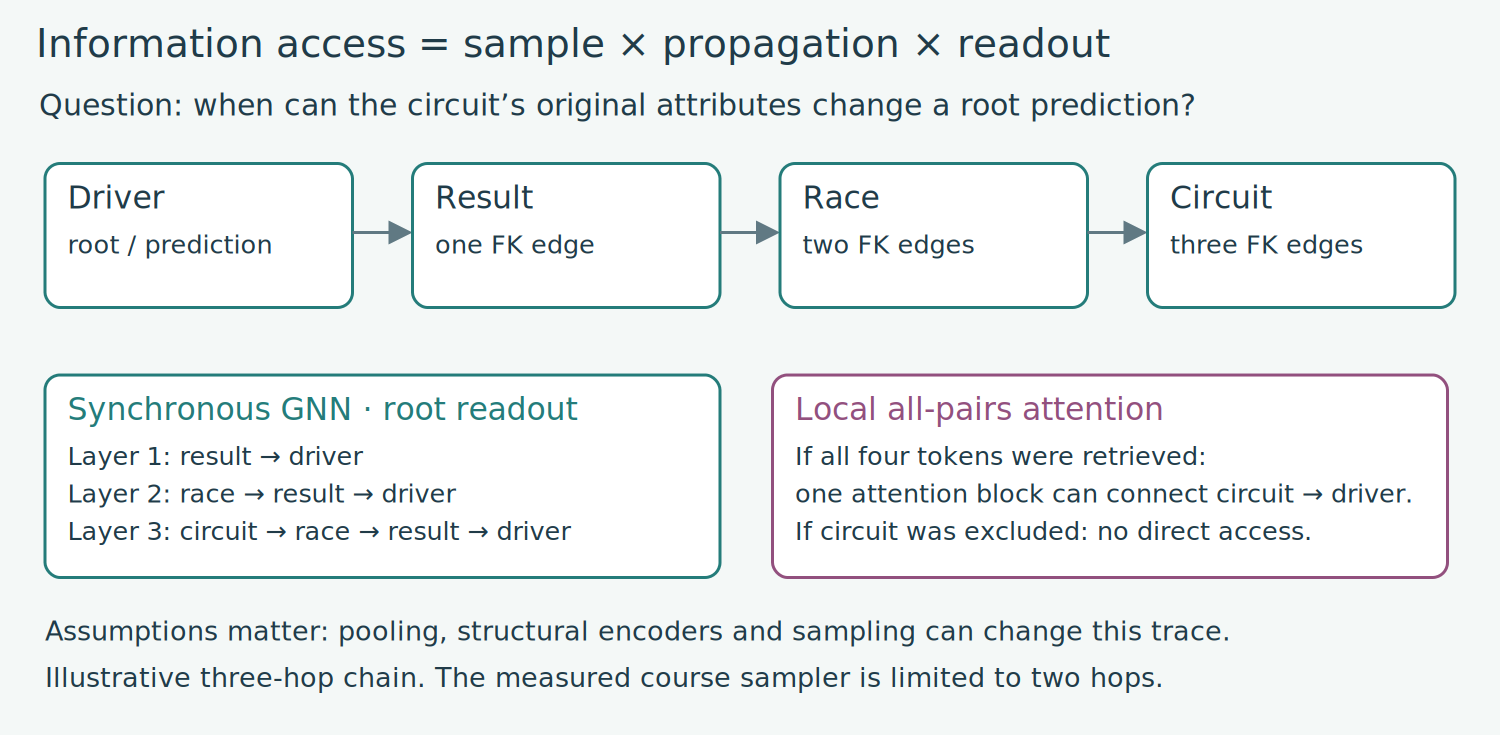<figcaption>Trace original row attributes under an explicit sampling, propagation and root-readout contract. Illustrative chain; not a benchmark result. Scroll horizontally for detail on a narrow screen.</figcaption></figure>
Baseline: circuit sampled, bridge legal, two GNN layers. Root-readout GNN cannot yet use circuit attributes; all-pairs attention can.

**Predict before moving the controls.** If the circuit is absent from the sample, will adding attention heads recover its attributes? If the result is a future row, should the sampler reach the otherwise old race through it?

**The answer has two parts.** Attention cannot recover an excluded row. A future bridge must be rejected before expansion. Validating only the last row's timestamp allows an illegal path to carry information into an earlier prediction.

The actual course sampler below uses at most two hops. The three-hop chain is an explanatory intervention, not a claim that the measured model saw circuits through that route. See [RelGT §3.2](https://arxiv.org/html/2505.10960v1#S3.SS2) for local all-pairs attention; inspect the [visible course sampler](https://avistian.github.io/relational/labs/relkit/comparison_l146.py) for the executed access rule.



## 2 · A winner needs a selection rule

> **In plain terms.** “Choose the best configuration” is incomplete. Best on which data, at which stage, and under which tie rule?

A **checkpoint** is the saved state after an epoch. A **configuration** specifies the architecture and training settings for a fit. Choosing a checkpoint inside each fit and choosing a configuration across fits are two separate decisions. Both need a rule fixed before looking at test scores.

**Worked example from the reported table.** The F1 row in RelGT's Table 6 contains nine configurations. The smallest displayed validation MAE is **3.1046**, at four layers and dropout **0.3**. Its displayed test MAE is **4.6316**. The headline test MAE **3.9170** belongs to one layer and dropout **0.5**, whose displayed validation MAE is **3.3257**.

<figure class="cmp-figure" tabindex="0">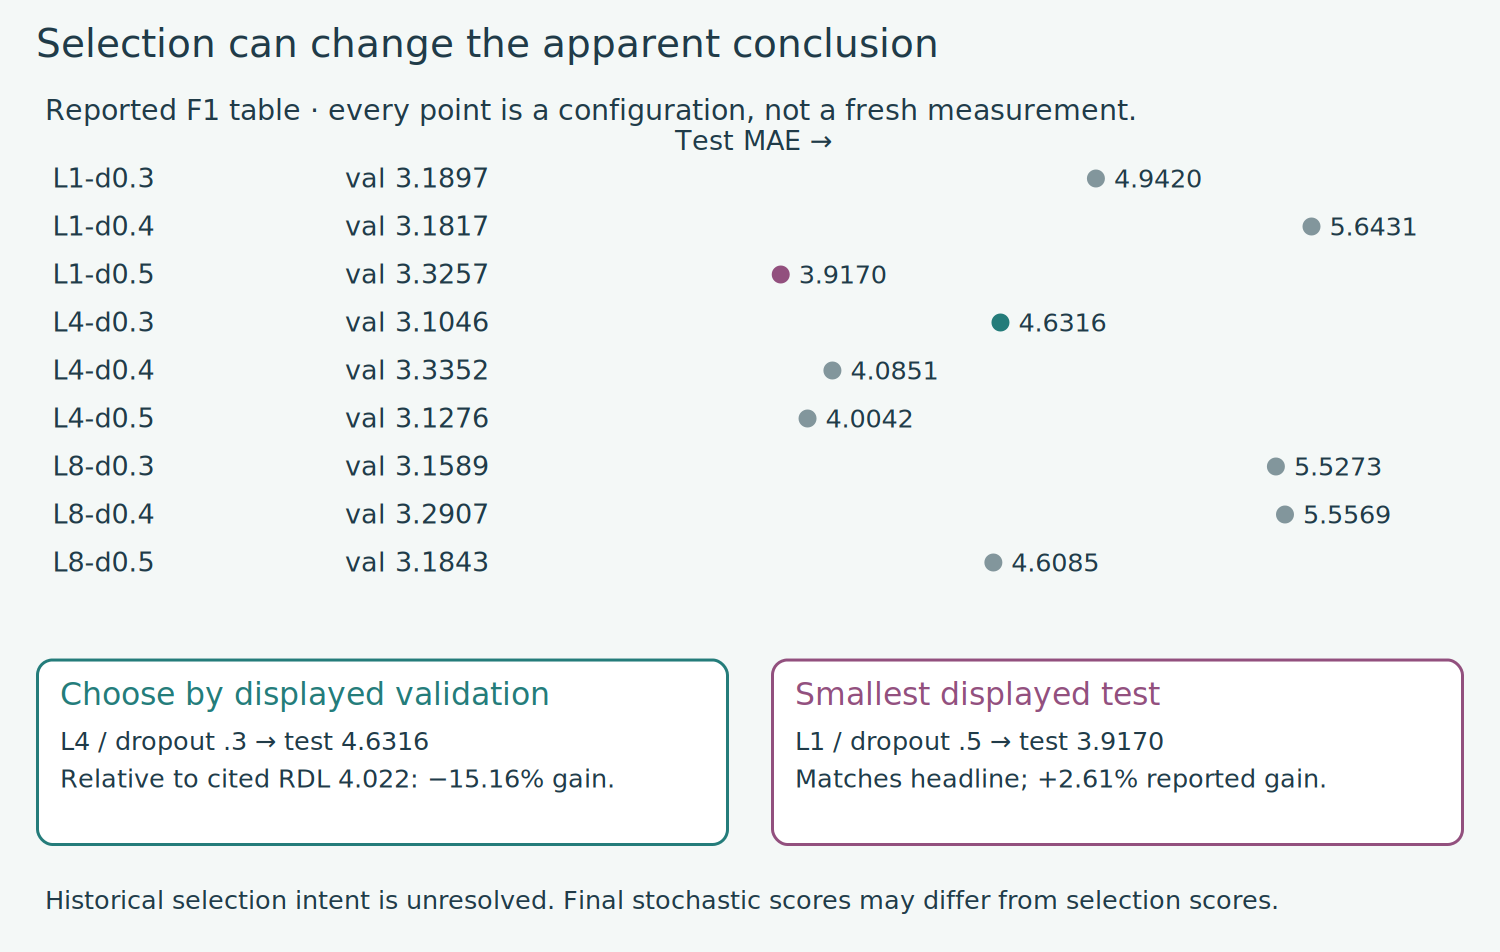<figcaption>Table 6 arithmetic under two declared selectors. Matching a test minimum does not establish historical selection intent. Scroll horizontally for detail on a narrow screen.</figcaption></figure>
Validation minimum: L4/.3 → test4.6316. Test minimum: L1/.5 → test3.917. Historical selection remains unresolved.

**A precise inference.** Selecting by the displayed validation row changes the apparent comparison with the cited RDL score, **4.022**. It does not prove which rule the authors actually used. The released trainer allows tied validation minima to replace an earlier checkpoint and reevaluates the saved model. Its evaluation is stochastic. Printed rounded final scores need not equal the selection-time values. The inspected trainer and launch script do not resolve historical cross-configuration selection.

> **Scope check.** This is an arithmetic audit of [Tables 1 and 6](https://arxiv.org/html/2505.10960v1#A4), not new training and not an accusation of test-set tuning. Historical selection is **NOT_ESTABLISHED**. [Machine-readable table and calculation](https://avistian.github.io/relational/labs/evidence/l146/paper-table.json).

**Your rule in the lab.** `select_config(configs, validation)` accepts no test scores. It chooses the first minimum and rejects incomplete or nonfinite scores. The same live function chooses checkpoints in the course trainer. This deliberately differs from the release's last-tie rule. A function signature cannot police where callers obtained a number; the protocol and audit still matter.

**Keep selection precision separate from display precision.** Here is a synthetic two-configuration example, not a reconstruction of the paper's hidden scores:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:.4em .25em"><thead><tr><th>Config</th><th>Stored validation MAE</th><th>Printed to 4 decimals</th></tr></thead><tbody><tr><td>A</td><td>3.10464</td><td>3.1046</td></tr><tr><td>B</td><td>3.10461</td><td>3.1046</td></tr></tbody></table>

The actual first-minimum selector chooses **B** from stored values. Applied to printed values, it sees a tie and chooses **A**. Display rounding has discarded selection evidence. Store the original metric and selected identity together; round only the presentation. This explains one limit of a printed-table audit without asserting that rounding caused the published discrepancy above.

**Try it after the example.** Reverse the configuration order. Which answer changes under exact values, and which changes under rounded values? <details><summary>Check your reasoning</summary>The exact minimum remains B. Under the rounded tie, the first item is now B, so the answer changes with order. A deterministic tie rule cannot recover precision that has already been discarded.</details>



## 3 · Freeze a comparison that can actually run

The paper experiment and the course experiment answer different questions. The complete paper-aligned RelGT runner retains all nine 100-epoch schedules. Lesson 145's temporal failure and cost estimate prevent calling its outputs a clean reproduction. We retain that runner and the canonical RDL runner; neither receives a fresh full paper-protocol fit in this lesson.

The new experiment asks a narrower question: **on the full F1 query population, how do two small model designs behave with identical legal sampled contexts and a fixed training recipe?**

<figure class="cmp-figure" tabindex="0">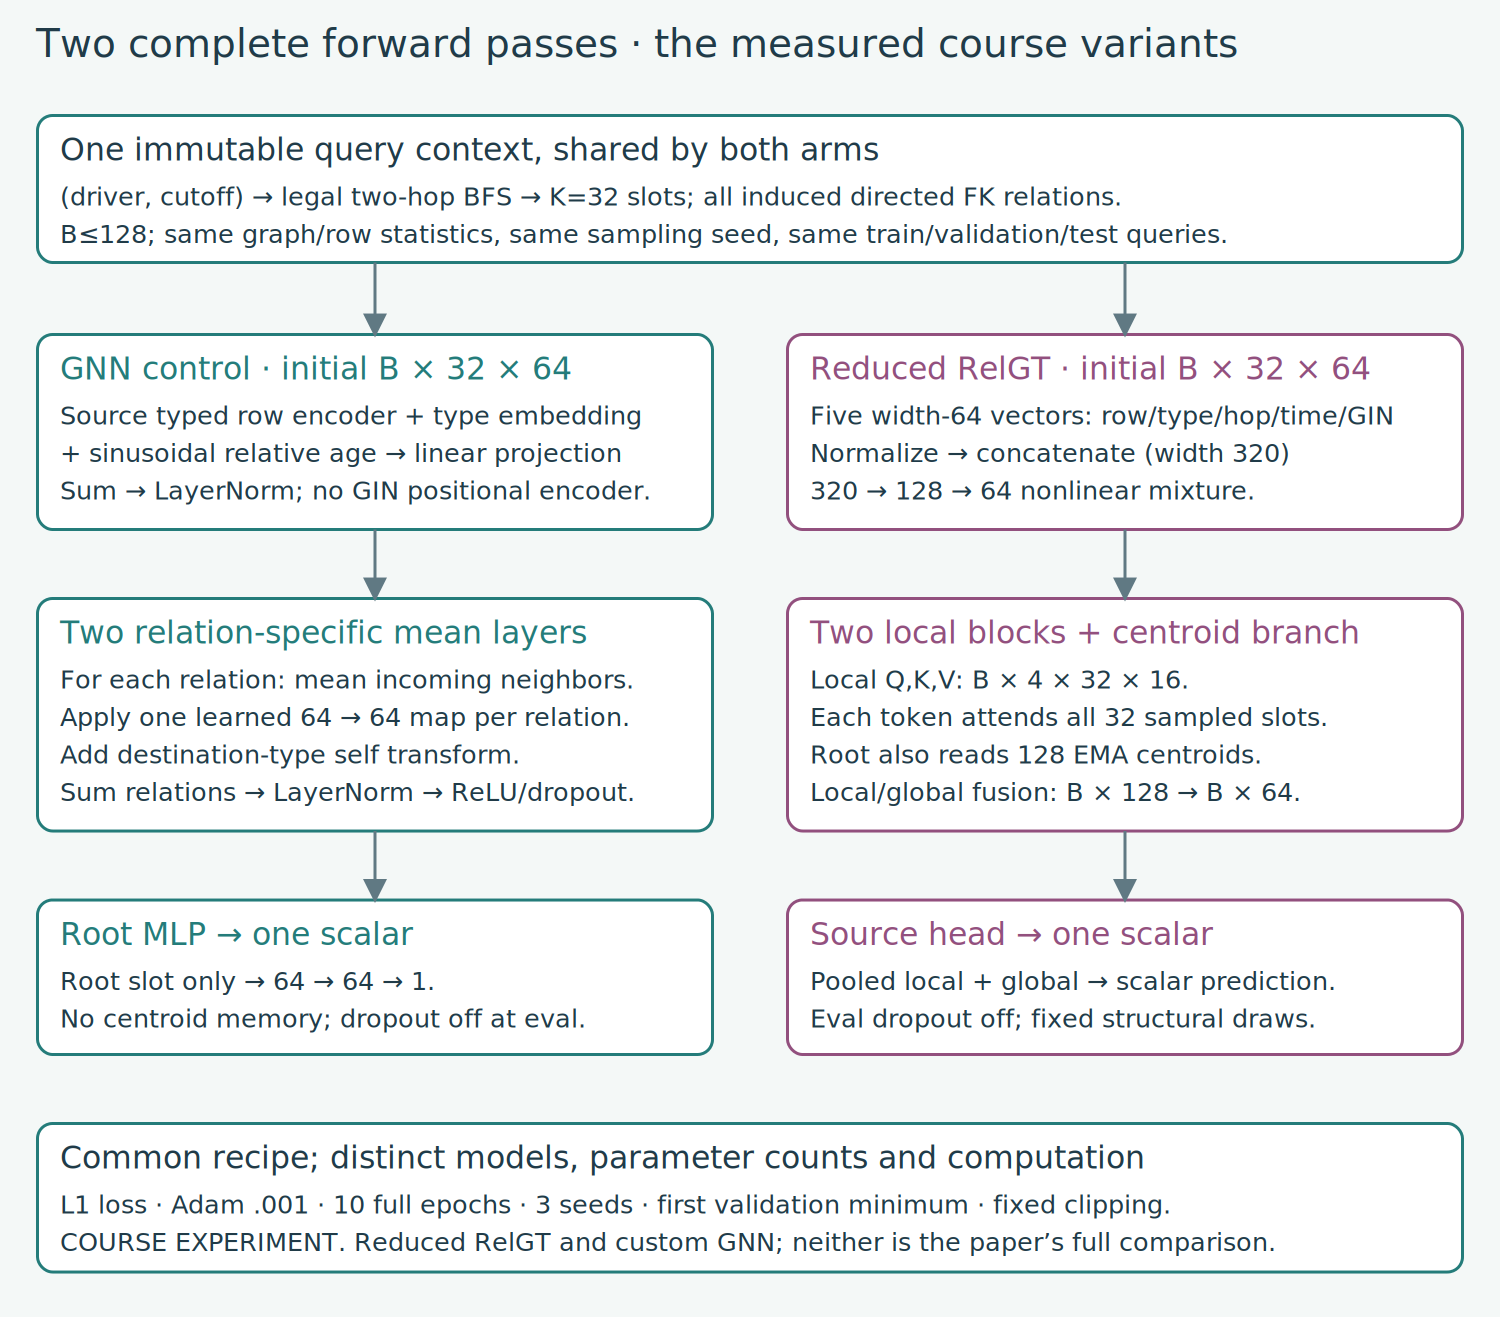<figcaption>The actual two reduced course variants, including input shapes, internal operations, readouts and training boundaries. Scroll horizontally for detail on a narrow screen.</figcaption></figure>

**Common input.** Both arms receive the same 32 token slots for each `(driver, cutoff)` and the same induced FK edges. Both use the source typed row encoder. Query-specific breadth-first sampling admits only rows at or before the owner cutoff, expands at most two hops, and keeps selected connectors. If too few rows exist, it repeats already selected legal rows. It never fills from arbitrary database rows. Every repeated slot gets its incident edges; an isolated query repeats its root. Repetition changes attention multiplicity and aggregation weights, so its frequency is reported.

**The GNN control.** Add row, table-type and relative-time vectors. Each of two layers transforms the destination's own state and adds a separate neighbor mean for each directed FK relation. Normalize, apply ReLU/dropout, and read the root through an MLP. For one relation with neighbor scalars 2 and 6, the mean is 4; adding ten unrelated rows does not alter that relation mean unless they enter that relation's neighborhood.

**The reduced RelGT arm.** Normalize and concatenate row, type, hop, time and GIN structural vectors. Mix them to width 64. Two local attention blocks compute interactions within 32 tokens; the root also attends to 128 EMA centroids through the source global branch. Fuse the branches and predict. Evaluation attention dropout is disabled, and structural normal draws are fixed for the evaluation batch layout. GPU aggregation still permits tiny floating-point ordering differences, checked within 0.00001 absolute. These are declared corrections, not claims about historical paper behavior.

**Common training.** Three paired seed labels, 0–2; ten complete epochs; batch 128; Adam at 0.001 with weight decay 0.00001; L1 loss; gradient norm clipping at 1. Each arm selects its own first minimum validation checkpoint. Test scoring occurs after that selection. Output clipping uses training-label percentiles 2 and 98. There is no hyperparameter search, discarded seed, or test-driven retuning.

**What remains different.** Parameter counts, structural encodings, relation handling, pooling, centroid state and random-number consumption differ. Equal seed numbers do not imply equal initial weights. Equal epochs do not imply equal GPU seconds. This tests two model designs under a common recipe; it does not isolate attention as the cause of any gap. The GNN control is not the canonical RDL baseline from the paper.

> **Scope check.** Full task coverage is not full paper reproduction. Graph features and statistics reuse the hash-verified L143 snapshot, including its transductive preprocessing. Event-time checks do not establish historical feature-arrival legality. The fixed test population has appeared in earlier course lessons; these results are descriptive rather than a new untouched confirmatory test. [Frozen protocol and deviations](https://avistian.github.io/relational/labs/l146-reproduction.md).



## 4 · Pair the errors, then limit the claim

> **In plain terms.** Compare the two models on exactly the same questions. A row position is not an identity.

A query key is `(driver ID, cutoff)`. For query q, define the error difference:

`difference[q] = abs(GNN[q] − target[q]) − abs(RelGT[q] − target[q])`.

Positive values favor RelGT; negative values favor the GNN. **Worked example:** for target 5, GNN prediction 8 and RelGT prediction 6, the difference is `3 − 1 = +2`. Shuffling one prediction file must not change the answer. Missing, duplicate, or mismatched keys must fail loudly.

First average over the full query population within each seed pair. Then report the mean and sample standard deviation across the three seed differences. This standard deviation describes seed variation; it is not a confidence interval. Repeated drivers and related cutoff windows also make an independent-row significance test unjustified here.

Predict before reading the author scores: does lower validation error guarantee lower test error?

| Full-data course arm | Validation MAE, mean ± seed SD | Test MAE, mean ± seed SD | Parameters |
|---|---:|---:|---:|
| Typed-mean GNN | 3.197652 ± 0.056532 | 4.293632 ± 0.037816 | 3,485,825 |
| Reduced corrected RelGT | 3.048312 ± 0.102734 | 4.617536 ± 0.291141 | 3,359,558 |

**Paired GNN − RelGT test difference: -0.323904 ± 0.253784 MAE** (sample seed SD). Positive favors RelGT. Per-seed differences: -0.075640, -0.582870, -0.313201.

All **7,554 primary held-out predictions** independently aligned and rescored. Six fresh fits each covered all **7,453 training queries for ten epochs**. Both arms used the same **499 validation / 760 test** keys. The sampler rebuilt all **8,712 labels** and passed its event-time audit. Repeated legal token slots: **43,000 train / 1,228 validation / 10,623 test**. These are occurrences, not distinct rows.

**Full selected paper reproduction: INCOMPLETE.** Nine full RelGT fits and a fresh canonical RDL comparator: **NOT_RUN**. Historical identity/selection: **NOT_ESTABLISHED**. Whole paper: **NOT_RUN**. Course runs do not change these verdicts.

<figure class="cmp-figure" tabindex="0">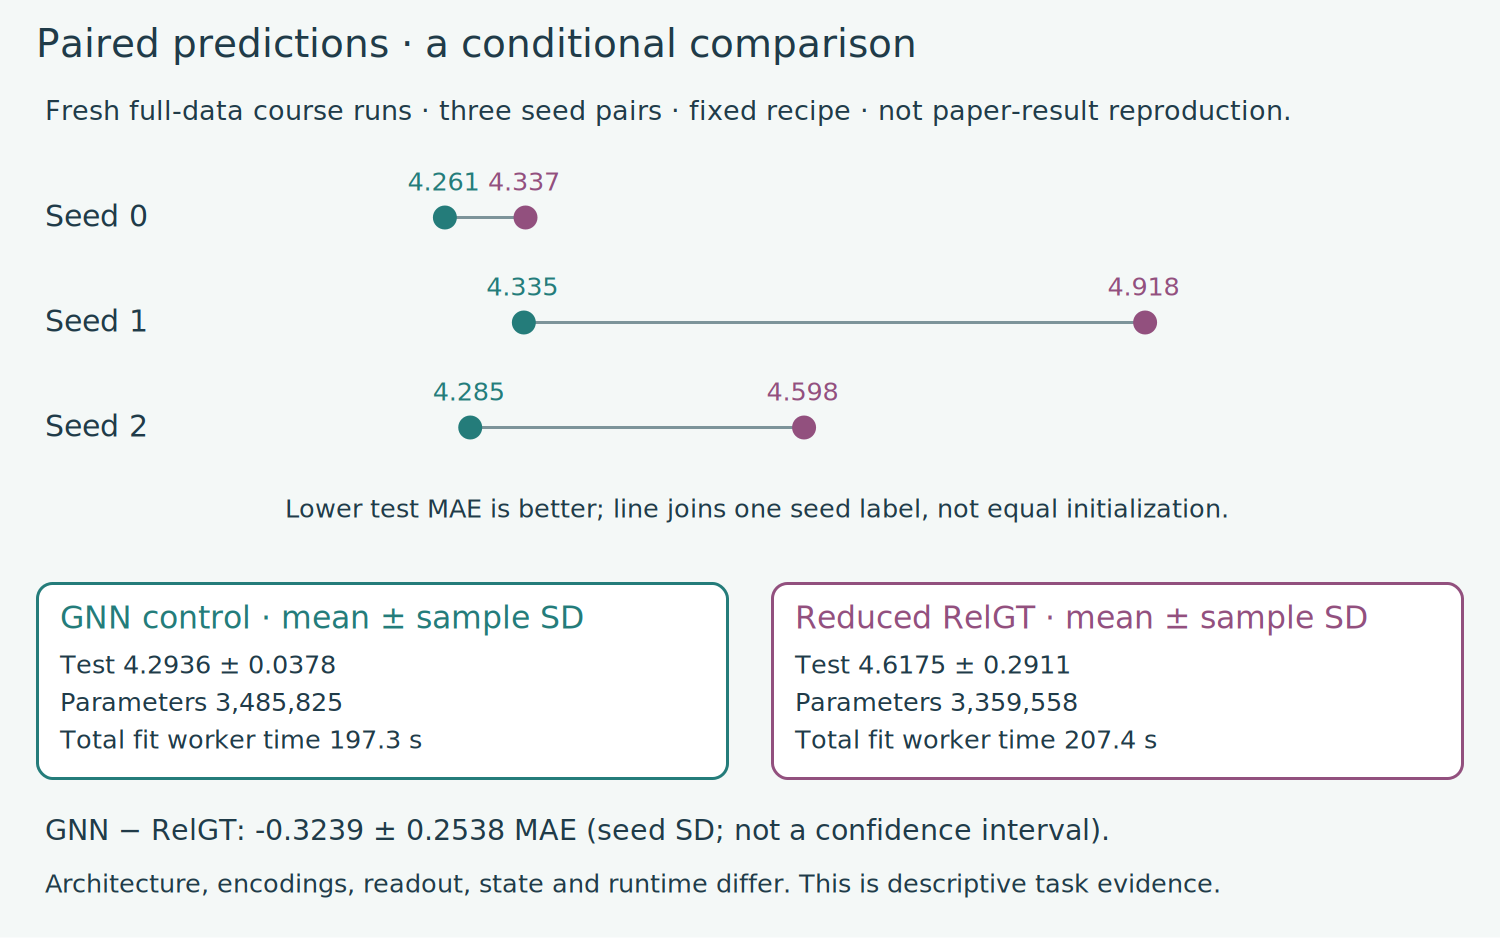<figcaption>Three fresh seed pairs on the full task. Sample seed SD is not a confidence interval. The two models have distinct mechanisms and runtime. Scroll horizontally for detail on a narrow screen.</figcaption></figure>

**What happened here.** Reduced RelGT has lower validation MAE in all three pairs, while the GNN has lower test MAE in all three. This does not identify the cause: tuning, regularization, distribution shift and architectural differences remain entangled. We keep the frozen settings and report the reversal; changing the recipe after seeing test scores would answer a new question.

**Read the result as a conditional statement.** Name the task, sampling rule, preprocessing, model sizes, training budget and selection rule. Explain what the difference measures and which architectural cause remains unisolated. A lower error here cannot establish that one paradigm dominates relational databases.



## 5 · Lab: make the contract executable

[Open the prepared notebook](https://avistian.github.io/relational/labs/html/0146-gnn-vs-graph-transformer.html) · [Student notebook](https://avistian.github.io/relational/labs/0146-gnn-vs-graph-transformer.ipynb) · [Reference solution](https://avistian.github.io/relational/labs/solutions/0146-gnn-vs-graph-transformer.ipynb).

1. **TODO: legal context.** Keep the original query cutoff through expansion and handle isolated roots without global fallback. Checks include a future bridge leading to an otherwise legal row.
2. **TODO: select with validation.** Reject an incomplete search and preserve the first-tie rule. Apply your function to the paper's displayed validation row and the saved training histories.
3. **TODO: paired errors.** Align both arms by full keys before computing differences. Checks intentionally shuffle predictions and inject duplicates.

The full row encoders, attention, centroid updates, typed message passing and training loop are visible in the notebook. Default execution runs synthetic mechanism checks and independently scores **saved author evidence**. It does not silently rerun the six remote fits. The explicit course gate requires prepared data; the source-reproduction preflight remains separate.

**Exit defense.** Write 150–200 words: what the selected comparison establishes; why the printed selection discrepancy remains unresolved; which two changes would make a stronger causal experiment; and why a passing temporal audit does not prove historical availability. Suggest changing one thing at a time—for example, a matched five-element encoder/readout comparison or a prespecified equal-compute search—without promising either would reverse the ranking.

Write your defense before viewing the reference answer; ask the teaching agent for feedback.

Ask the teaching agent about any unclear path, tensor, metric or evidence boundary. Completing the author's notebook is not your mastery record. Your status remains **PENDING_WRITTEN_DEFENSE** until you submit and defend your explanation.



## Read, retrieve, then return

Primary reading: [RelGT §4 and Appendix A.4](https://arxiv.org/html/2505.10960v1#S4), alongside the [pinned release](https://github.com/snap-stanford/relgt/tree/19e423ca3e7cac761130aba790857f2dc3a46ef7). Trace `main_node_ddp.py`'s within-fit selection separately from the sweep launcher. Revisit [the comparison reference](https://avistian.github.io/relational/reference/gnn-vs-graph-transformer.html) tomorrow, then answer without looking: “What makes two scores comparable?”

Lesson 147 will turn these distinctions into a survey question: which open architectural problems have both a plausible mechanism and a tractable falsification experiment?


<!-- sequence-next:start -->
**Carry this forward.** Turn the unresolved comparison into a research question in Lesson 147. Name a missing measurement before proposing a larger model. [Continue to Lesson 147](https://avistian.github.io/relational/lessons/0147-next-generation-architectures.html).
<!-- sequence-next:end -->


In [ ]:
# PROVIDED: immutable author evidence plus pinned MIT original sources.
AUTHOR_FILES=json.loads(zlib.decompress(base64.b64decode('...')))
SOURCE_FILES=json.loads(zlib.decompress(base64.b64decode('...')))
SOURCE_ROOT=Path('sources/l145');SOURCE_ROOT.mkdir(parents=True,exist_ok=True)
for name,source in SOURCE_FILES.items():(SOURCE_ROOT/name).write_text(source)
AUTHOR_SUMMARY={'status': 'PASS', 'course_experiment': 'COMPLETE', 'runs': [{'run_id': 'fit-gnn-0', 'arm': 'gnn', 'seed': 0, 'config': {'k': 32, 'width': 64, 'layers': 2, 'dropout': 0.1, 'centroids': 128, 'global_dim': 32, 'batch': 128, 'epochs': 10, 'lr': 0.001, 'weight_decay': 1e-05, 'seeds': [0, 1, 2], 'sampler_seed': 146}, 'pilot': False, 'history': [{'epoch': 1, 'queries': 7453, 'val_mae': 4.293053332184185, 'train_seconds': 7.591451007, 'val_seconds': 0.13875282800000122}, {'epoch': 2, 'queries': 7453, 'val_mae': 3.6568703364115516, 'train_seconds': 6.219736763, 'val_seconds': 0.1299494569999986}, {'epoch': 3, 'queries': 7453, 'val_mae': 3.2821447102324357, 'train_seconds': 6.177064704999999, 'val_seconds': 0.13115028700000053}, {'epoch': 4, 'queries': 7453, 'val_mae': 3.4333028334653926, 'train_seconds': 6.318058456000003, 'val_seconds': 0.13308761800000468}, {'epoch': 5, 'queries': 7453, 'val_mae': 3.290789546023708, 'train_seconds': 6.282376421999999, 'val_seconds': 0.13259388099999825}, {'epoch': 6, 'queries': 7453, 'val_mae': 3.2757477738655, 'train_seconds': 6.273498606000004, 'val_seconds': 0.1307445549999997}, {'epoch': 7, 'queries': 7453, 'val_mae': 3.349751067750838, 'train_seconds': 6.265784176000004, 'val_seconds': 0.13311351000000116}, {'epoch': 8, 'queries': 7453, 'val_mae': 3.2578852056581016, 'train_seconds': 6.328415718000002, 'val_seconds': 0.12972373000000204}, {'epoch': 9, 'queries': 7453, 'val_mae': 3.356951278706909, 'train_seconds': 6.268389310999993, 'val_seconds': 0.13640491399999632}, {'epoch': 10, 'queries': 7453, 'val_mae': 3.2225797151197333, 'train_seconds': 6.212548763000001, 'val_seconds': 0.12954251600000077}], 'scores': {'val': 3.2225796778518996, 'test': 4.261014471681494}, 'parameters': 3485825, 'selected_epoch': 10, 'first_batch_nonfinite_gradients': {}, 'gradient_evidence': 'Original trainer checked every batch; all ten epochs completed', 'repeat_eval_max_error': 2.86102294921875e-06, 'seconds': 69.196086156, 'recovery_evaluation_seconds': 3.547641039, 'checkpoint_sha256': '1bb9b5f248159bef45f25508b3994dac731e0950773fbea3a19329d3845622ca', 'context_sha256': {'train': '7a8b77f2585f54ecce7d5d34f258cee8bbb21c1dd4cb1e3a2a141249e50d2ff2', 'val': '18112d6f50cbbf11c0ddf13c2f242c8a5d19d36a44e42523f96faf4e63eac26f', 'test': '69f2f8f519337b411fa00d12be565d254369dd73bbe2a77bb3c2f714e187133d'}, 'evidence': 'COURSE_EXPERIMENT', 'test': 'SCORED', 'recovery': 'Evaluation only after exact CUDA-repeat assertion; no retraining or checkpoint change'}, {'run_id': 'fit-relgt-0', 'arm': 'relgt', 'seed': 0, 'config': {'k': 32, 'width': 64, 'layers': 2, 'dropout': 0.1, 'centroids': 128, 'global_dim': 32, 'batch': 128, 'epochs': 10, 'lr': 0.001, 'weight_decay': 1e-05, 'seeds': [0, 1, 2], 'sampler_seed': 146}, 'pilot': False, 'history': [{'epoch': 1, 'queries': 7453, 'val_mae': 8.629886762062233, 'train_seconds': 9.364842377000002, 'val_seconds': 0.14454744100000028}, {'epoch': 2, 'queries': 7453, 'val_mae': 7.256721998869616, 'train_seconds': 6.9001673169999975, 'val_seconds': 0.12530605599999944}, {'epoch': 3, 'queries': 7453, 'val_mae': 5.030568725774508, 'train_seconds': 7.0079515950000015, 'val_seconds': 0.12318234800000027}, {'epoch': 4, 'queries': 7453, 'val_mae': 4.130951313026444, 'train_seconds': 7.200851978999999, 'val_seconds': 0.1357388670000006}, {'epoch': 5, 'queries': 7453, 'val_mae': 4.029330976915583, 'train_seconds': 7.160598774999997, 'val_seconds': 0.11956963199999393}, {'epoch': 6, 'queries': 7453, 'val_mae': 3.244713411987345, 'train_seconds': 7.043969498000003, 'val_seconds': 0.11754822999999703}, {'epoch': 7, 'queries': 7453, 'val_mae': 3.995374987391368, 'train_seconds': 6.834665524999998, 'val_seconds': 0.1270793840000124}, {'epoch': 8, 'queries': 7453, 'val_mae': 3.555856422177138, 'train_seconds': 6.765256633999996, 'val_seconds': 0.13203680000000872}, {'epoch': 9, 'queries': 7453, 'val_mae': 3.147865335926981, 'train_seconds': 7.144959671999999, 'val_seconds': 0.13061795000000131}, {'epoch': 10, 'queries': 7453, 'val_mae': 3.413138842789746, 'train_seconds': 7.237784719999993, 'val_seconds': 0.129685803000001}], 'scores': {'val': 3.1478653464384214, 'test': 4.3366547067541825}, 'parameters': 3359558, 'selected_epoch': 9, 'first_batch_nonfinite_gradients': {}, 'gradient_evidence': 'Original trainer checked every batch; all ten epochs completed', 'repeat_eval_max_error': 3.814697265625e-06, 'seconds': 79.944954036, 'recovery_evaluation_seconds': 3.3556697609999997, 'checkpoint_sha256': '3a1ec1152489c2f5fb09300c6c98e2205b42a83e413afc53be5e1b3874fa2820', 'context_sha256': {'train': '7a8b77f2585f54ecce7d5d34f258cee8bbb21c1dd4cb1e3a2a141249e50d2ff2', 'val': '18112d6f50cbbf11c0ddf13c2f242c8a5d19d36a44e42523f96faf4e63eac26f', 'test': '69f2f8f519337b411fa00d12be565d254369dd73bbe2a77bb3c2f714e187133d'}, 'evidence': 'COURSE_EXPERIMENT', 'test': 'SCORED', 'recovery': 'Evaluation only after exact CUDA-repeat assertion; no retraining or checkpoint change'}, {'run_id': 'fit-gnn-1', 'arm': 'gnn', 'seed': 1, 'config': {'k': 32, 'width': 64, 'layers': 2, 'dropout': 0.1, 'centroids': 128, 'global_dim': 32, 'batch': 128, 'epochs': 10, 'lr': 0.001, 'weight_decay': 1e-05, 'seeds': [0, 1, 2], 'sampler_seed': 146}, 'pilot': False, 'history': [{'epoch': 1, 'queries': 7453, 'val_mae': 4.313807714407494, 'train_seconds': 7.22956087, 'val_seconds': 0.12541091599999987}, {'epoch': 2, 'queries': 7453, 'val_mae': 4.090032204708897, 'train_seconds': 6.161947351000002, 'val_seconds': 0.157807131000002}, {'epoch': 3, 'queries': 7453, 'val_mae': 3.689427476002522, 'train_seconds': 6.043049336000003, 'val_seconds': 0.12901968899999972}, {'epoch': 4, 'queries': 7453, 'val_mae': 3.1466623740110222, 'train_seconds': 5.788564791000002, 'val_seconds': 0.11982901900000087}, {'epoch': 5, 'queries': 7453, 'val_mae': 3.1802268458272747, 'train_seconds': 5.571823737999999, 'val_seconds': 0.11868340099999841}, {'epoch': 6, 'queries': 7453, 'val_mae': 3.132940762506458, 'train_seconds': 5.532018809999997, 'val_seconds': 0.11993047899999709}, {'epoch': 7, 'queries': 7453, 'val_mae': 3.253438577097738, 'train_seconds': 5.430073304000004, 'val_seconds': 0.11865772000000163}, {'epoch': 8, 'queries': 7453, 'val_mae': 3.218708743998108, 'train_seconds': 5.444843354999996, 'val_seconds': 0.11791579599999835}, {'epoch': 9, 'queries': 7453, 'val_mae': 3.392399925761965, 'train_seconds': 5.561013867999996, 'val_seconds': 0.12412165499999617}, {'epoch': 10, 'queries': 7453, 'val_mae': 3.5729606014295032, 'train_seconds': 5.824589191999991, 'val_seconds': 0.11994641500000114}], 'scores': {'val': 3.1329407902184374, 'test': 4.335083300021657}, 'parameters': 3485825, 'selected_epoch': 6, 'first_batch_nonfinite_gradients': {}, 'gradient_evidence': 'Original trainer checked every batch; all ten epochs completed', 'repeat_eval_max_error': 2.86102294921875e-06, 'seconds': 63.194537012, 'recovery_evaluation_seconds': 2.931859242999998, 'checkpoint_sha256': '5c974224bffc6d614176b87613a8df9d43a4806658e47a3484d28eecbdc18228', 'context_sha256': {'train': '7a8b77f2585f54ecce7d5d34f258cee8bbb21c1dd4cb1e3a2a141249e50d2ff2', 'val': '18112d6f50cbbf11c0ddf13c2f242c8a5d19d36a44e42523f96faf4e63eac26f', 'test': '69f2f8f519337b411fa00d12be565d254369dd73bbe2a77bb3c2f714e187133d'}, 'evidence': 'COURSE_EXPERIMENT', 'test': 'SCORED', 'recovery': 'Evaluation only after exact CUDA-repeat assertion; no retraining or checkpoint change'}, {'run_id': 'fit-relgt-1', 'arm': 'relgt', 'seed': 1, 'config': {'k': 32, 'width': 64, 'layers': 2, 'dropout': 0.1, 'centroids': 128, 'global_dim': 32, 'batch': 128, 'epochs': 10, 'lr': 0.001, 'weight_decay': 1e-05, 'seeds': [0, 1, 2], 'sampler_seed': 146}, 'pilot': False, 'history': [{'epoch': 1, 'queries': 7453, 'val_mae': 8.693801892400982, 'train_seconds': 7.404285896999999, 'val_seconds': 0.10563120799999837}, {'epoch': 2, 'queries': 7453, 'val_mae': 6.7565092624468095, 'train_seconds': 5.608889756, 'val_seconds': 0.12587417199999962}, {'epoch': 3, 'queries': 7453, 'val_mae': 6.098167641734631, 'train_seconds': 6.1483753939999986, 'val_seconds': 0.09097898799999626}, {'epoch': 4, 'queries': 7453, 'val_mae': 3.8017445354996795, 'train_seconds': 6.578404831, 'val_seconds': 0.1211739190000003}, {'epoch': 5, 'queries': 7453, 'val_mae': 3.6562654640488255, 'train_seconds': 5.960186158000006, 'val_seconds': 0.09689414200000357}, {'epoch': 6, 'queries': 7453, 'val_mae': 3.054401877026759, 'train_seconds': 5.8864942140000025, 'val_seconds': 0.09876724600000131}, {'epoch': 7, 'queries': 7453, 'val_mae': 3.1119991314594317, 'train_seconds': 5.563113044000005, 'val_seconds': 0.0927735109999972}, {'epoch': 8, 'queries': 7453, 'val_mae': 3.1373510967833087, 'train_seconds': 5.506850299, 'val_seconds': 0.09983522599999617}, {'epoch': 9, 'queries': 7453, 'val_mae': 3.1758853718051134, 'train_seconds': 6.235187617000001, 'val_seconds': 0.09357232299998941}, {'epoch': 10, 'queries': 7453, 'val_mae': 3.540741210343763, 'train_seconds': 5.43218073700001, 'val_seconds': 0.09046989399999461}], 'scores': {'val': 3.0544019114278367, 'test': 4.9179529318893165}, 'parameters': 3359558, 'selected_epoch': 6, 'first_batch_nonfinite_gradients': {}, 'gradient_evidence': 'Original trainer checked every batch; all ten epochs completed', 'repeat_eval_max_error': 2.86102294921875e-06, 'seconds': 64.94762082300001, 'recovery_evaluation_seconds': 2.967184408999998, 'checkpoint_sha256': 'ccf03585e3868938d7c39f68bd692b7a4170b55e1fcf76bc5d94d0fdc3e58b93', 'context_sha256': {'train': '7a8b77f2585f54ecce7d5d34f258cee8bbb21c1dd4cb1e3a2a141249e50d2ff2', 'val': '18112d6f50cbbf11c0ddf13c2f242c8a5d19d36a44e42523f96faf4e63eac26f', 'test': '69f2f8f519337b411fa00d12be565d254369dd73bbe2a77bb3c2f714e187133d'}, 'evidence': 'COURSE_EXPERIMENT', 'test': 'SCORED', 'recovery': 'Evaluation only after exact CUDA-repeat assertion; no retraining or checkpoint change'}, {'run_id': 'fit-gnn-2', 'arm': 'gnn', 'seed': 2, 'config': {'k': 32, 'width': 64, 'layers': 2, 'dropout': 0.1, 'centroids': 128, 'global_dim': 32, 'batch': 128, 'epochs': 10, 'lr': 0.001, 'weight_decay': 1e-05, 'seeds': [0, 1, 2], 'sampler_seed': 146}, 'pilot': False, 'history': [{'epoch': 1, 'queries': 7453, 'val_mae': 4.209911434986469, 'train_seconds': 7.291013561, 'val_seconds': 0.13107813399999912}, {'epoch': 2, 'queries': 7453, 'val_mae': 3.310431471042977, 'train_seconds': 6.056994412999998, 'val_seconds': 0.12291978999999742}, {'epoch': 3, 'queries': 7453, 'val_mae': 3.374892718328503, 'train_seconds': 5.788462408000001, 'val_seconds': 0.1257967089999994}, {'epoch': 4, 'queries': 7453, 'val_mae': 3.589911444567806, 'train_seconds': 5.736399049999999, 'val_seconds': 0.12162581900000191}, {'epoch': 5, 'queries': 7453, 'val_mae': 3.310328119567178, 'train_seconds': 5.794264570000003, 'val_seconds': 0.12270389700000095}, {'epoch': 6, 'queries': 7453, 'val_mae': 3.3040657060657566, 'train_seconds': 5.785320737999996, 'val_seconds': 0.124866861000001}, {'epoch': 7, 'queries': 7453, 'val_mae': 3.3520855917003685, 'train_seconds': 5.816265545, 'val_seconds': 0.1250632340000024}, {'epoch': 8, 'queries': 7453, 'val_mae': 3.237436377436779, 'train_seconds': 5.8207799489999985, 'val_seconds': 0.12810906800000055}, {'epoch': 9, 'queries': 7453, 'val_mae': 3.2616815786801263, 'train_seconds': 6.033146180000003, 'val_seconds': 0.12273349299999836}, {'epoch': 10, 'queries': 7453, 'val_mae': 3.342949232484949, 'train_seconds': 5.794034659999994, 'val_seconds': 0.12358235199999967}], 'scores': {'val': 3.2374364118378565, 'test': 4.2847977102848525}, 'parameters': 3485825, 'selected_epoch': 8, 'first_batch_nonfinite_gradients': {}, 'gradient_evidence': 'Original trainer checked every batch; all ten epochs completed', 'repeat_eval_max_error': 2.86102294921875e-06, 'seconds': 64.944154924, 'recovery_evaluation_seconds': 3.0599910979999976, 'checkpoint_sha256': 'bd5a73b45084a1e1bc93a4eff48eedaea28acc043f053db0b850ed2b84b6508b', 'context_sha256': {'train': '7a8b77f2585f54ecce7d5d34f258cee8bbb21c1dd4cb1e3a2a141249e50d2ff2', 'val': '18112d6f50cbbf11c0ddf13c2f242c8a5d19d36a44e42523f96faf4e63eac26f', 'test': '69f2f8f519337b411fa00d12be565d254369dd73bbe2a77bb3c2f714e187133d'}, 'evidence': 'COURSE_EXPERIMENT', 'test': 'SCORED', 'recovery': 'Evaluation only after exact CUDA-repeat assertion; no retraining or checkpoint change'}, {'run_id': '4c2aeae5-fa4b-4382-8073-5333a326a37e', 'arm': 'relgt', 'seed': 2, 'config': {'k': 32, 'width': 64, 'layers': 2, 'dropout': 0.1, 'centroids': 128, 'global_dim': 32, 'batch': 128, 'epochs': 10, 'lr': 0.001, 'weight_decay': 1e-05, 'seeds': [0, 1, 2], 'sampler_seed': 146}, 'pilot': False, 'history': [{'epoch': 1, 'queries': 7453, 'val_mae': 9.062847264958128, 'train_seconds': 7.037737979999999, 'val_seconds': 0.10720712599999871}, {'epoch': 2, 'queries': 7453, 'val_mae': 7.94882351560599, 'train_seconds': 5.621283124000001, 'val_seconds': 0.09610264399999835}, {'epoch': 3, 'queries': 7453, 'val_mae': 5.713875163326123, 'train_seconds': 5.5714146960000015, 'val_seconds': 0.09613168999999999}, {'epoch': 4, 'queries': 7453, 'val_mae': 5.3814573069453315, 'train_seconds': 6.2083779040000024, 'val_seconds': 0.10474551499999762}, {'epoch': 5, 'queries': 7453, 'val_mae': 4.434051351604576, 'train_seconds': 5.774021624999996, 'val_seconds': 0.09777698299999571}, {'epoch': 6, 'queries': 7453, 'val_mae': 5.203548044575479, 'train_seconds': 5.766394081999998, 'val_seconds': 0.09786171599999705}, {'epoch': 7, 'queries': 7453, 'val_mae': 3.0567159145612597, 'train_seconds': 5.905586596999996, 'val_seconds': 0.09751260000000173}, {'epoch': 8, 'queries': 7453, 'val_mae': 3.189674171417175, 'train_seconds': 5.622372745, 'val_seconds': 0.09785803799999826}, {'epoch': 9, 'queries': 7453, 'val_mae': 3.2326864357223966, 'train_seconds': 5.667015657, 'val_seconds': 0.10104300399999033}, {'epoch': 10, 'queries': 7453, 'val_mae': 2.9426681742161693, 'train_seconds': 5.6773861270000054, 'val_seconds': 0.09664191899999253}], 'scores': {'val': 2.9426681637047287, 'test': 4.597998990050534}, 'parameters': 3359558, 'selected_epoch': 10, 'first_batch_nonfinite_gradients': {}, 'repeat_eval_max_error': 3.814697265625e-06, 'seconds': 62.555349733, 'checkpoint_sha256': '39523343267b653b8323b3ba87ab6380f2fe16288667986a24207a5ec0e7562a', 'context_sha256': {'train': '7a8b77f2585f54ecce7d5d34f258cee8bbb21c1dd4cb1e3a2a141249e50d2ff2', 'val': '18112d6f50cbbf11c0ddf13c2f242c8a5d19d36a44e42523f96faf4e63eac26f', 'test': '69f2f8f519337b411fa00d12be565d254369dd73bbe2a77bb3c2f714e187133d'}, 'evidence': 'COURSE_EXPERIMENT', 'test': 'SCORED'}], 'arms': {'gnn': {'parameters': 3485825, 'fit_seconds': 197.33477809200002, 'val': {'mean': 3.197652293302731, 'sample_sd': 0.05653197864707895, 'values': [3.2225796778518996, 3.1329407902184374, 3.2374364118378565]}, 'test': {'mean': 4.293631827329334, 'sample_sd': 0.037816386010403574, 'values': [4.261014471681494, 4.335083300021657, 4.2847977102848525]}}, 'relgt': {'parameters': 3359558, 'fit_seconds': 207.447924592, 'val': {'mean': 3.048311807190329, 'sample_sd': 0.10273406434907022, 'values': [3.1478653464384214, 3.0544019114278367, 2.9426681637047287]}, 'test': {'mean': 4.617535542898011, 'sample_sd': 0.2911411415605598, 'values': [4.3366547067541825, 4.9179529318893165, 4.597998990050534]}}}, 'paired': {'val': {'mean': 0.1493404861124022, 'sample_sd': 0.12595865299941678, 'differences': [0.07471433141347798, 0.0785388787906012, 0.2947682481331274], 'relgt_wins': 3}, 'test': {'mean': -0.3239037155686763, 'sample_sd': 0.25378400627765263, 'differences': [-0.07564023507268805, -0.5828696318676597, -0.31320127976568124], 'relgt_wins': 0}}, 'verified_predictions': 7554, 'full_selected_reproduction': 'INCOMPLETE', 'fresh_canonical_rdl': 'NOT_RUN', 'full_relgt_search': 'NOT_RUN', 'historical_identity': 'NOT_ESTABLISHED', 'whole_paper': 'NOT_RUN'}
AUTHOR_TABLE={'source': 'https://arxiv.org/html/2505.10960v1#A4', 'table': 6, 'configs': ['L1-d0.3', 'L1-d0.4', 'L1-d0.5', 'L4-d0.3', 'L4-d0.4', 'L4-d0.5', 'L8-d0.3', 'L8-d0.4', 'L8-d0.5'], 'validation': [3.1897, 3.1817, 3.3257, 3.1046, 3.3352, 3.1276, 3.1589, 3.2907, 3.1843], 'test': [4.942, 5.6431, 3.917, 4.6316, 4.0851, 4.0042, 5.5273, 5.5569, 4.6085], 'selected_by_displayed_validation': 'L4-d0.3', 'its_displayed_test': 4.6316, 'minimum_displayed_test_config': 'L1-d0.5', 'minimum_displayed_test': 3.917, 'headline_test': 3.917, 'rdl_test': 4.022, 'validation_selected_relative_gain_percent': -15.15663848831426, 'headline_relative_gain_percent': 2.6106414719045357, 'finding': 'Headline matches smallest displayed test; not the smallest displayed validation. Historical selection intent NOT_ESTABLISHED.', 'caveat': 'Printed rounded scores and stochastic final reevaluation cannot reconstruct the historical selection-time metrics.'}
AUTHOR_AUDIT={'status': 'PASS', 'config': {'k': 32, 'width': 64, 'layers': 2, 'dropout': 0.1, 'centroids': 128, 'global_dim': 32, 'batch': 128, 'epochs': 10, 'lr': 0.001, 'weight_decay': 1e-05, 'seeds': [0, 1, 2], 'sampler_seed': 146}, 'graph': {'graph_sha256': '6c72c684d51aaedbba11946d9babee705a7c0bc1e93415f4d48926b38973da99', 'checkpoint_sha256': '3ba2b6e5c99bc0939d13debb6b06d8d0f0828148361662d54bab83f6c23943df', 'checkpoint_revision': '321e6f6e7af5d7546b637f147783fc28ab5d4a7a', 'preprocessing': 'FRESH full released snapshot; seed42; pinned GloVe', 'archives': {'db.zip': 'ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482', 'tasks/driver-position.zip': '775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e'}, 'source_checks': {'graph': True, 'nn': True, 'utils': True}, 'rows': {'circuits': 77, 'constructor_results': 9408, 'constructor_standings': 10170, 'constructors': 211, 'drivers': 857, 'qualifying': 4082, 'races': 820, 'results': 20323, 'standings': 28115}, 'fk_edges': 169421, 'edges': 338842, 'routes': [['dim-fact-dim', 'constructor_results', 'f2p_raceId', 'races', 'constructors', 'rev_f2p_constructorId', 'constructor_results'], ['dim-fact-dim', 'constructor_results', 'f2p_constructorId', 'constructors', 'races', 'rev_f2p_raceId', 'constructor_results'], ['dim-fact-dim', 'constructor_standings', 'f2p_raceId', 'races', 'constructors', 'rev_f2p_constructorId', 'constructor_standings'], ['dim-fact-dim', 'constructor_standings', 'f2p_constructorId', 'constructors', 'races', 'rev_f2p_raceId', 'constructor_standings'], ['dim-fact-dim', 'qualifying', 'f2p_raceId', 'races', 'drivers', 'rev_f2p_driverId', 'qualifying'], ['dim-fact-dim', 'qualifying', 'f2p_raceId', 'races', 'constructors', 'rev_f2p_constructorId', 'qualifying'], ['dim-fact-dim', 'qualifying', 'f2p_driverId', 'drivers', 'races', 'rev_f2p_raceId', 'qualifying'], ['dim-fact-dim', 'qualifying', 'f2p_driverId', 'drivers', 'constructors', 'rev_f2p_constructorId', 'qualifying'], ['dim-fact-dim', 'qualifying', 'f2p_constructorId', 'constructors', 'races', 'rev_f2p_raceId', 'qualifying'], ['dim-fact-dim', 'qualifying', 'f2p_constructorId', 'constructors', 'drivers', 'rev_f2p_driverId', 'qualifying'], ['dim-dim', 'races', 'f2p_circuitId', 'circuits'], ['dim-dim', 'circuits', 'rev_f2p_circuitId', 'races'], ['dim-fact-dim', 'results', 'f2p_raceId', 'races', 'drivers', 'rev_f2p_driverId', 'results'], ['dim-fact-dim', 'results', 'f2p_raceId', 'races', 'constructors', 'rev_f2p_constructorId', 'results'], ['dim-fact-dim', 'results', 'f2p_driverId', 'drivers', 'races', 'rev_f2p_raceId', 'results'], ['dim-fact-dim', 'results', 'f2p_driverId', 'drivers', 'constructors', 'rev_f2p_constructorId', 'results'], ['dim-fact-dim', 'results', 'f2p_constructorId', 'constructors', 'races', 'rev_f2p_raceId', 'results'], ['dim-fact-dim', 'results', 'f2p_constructorId', 'constructors', 'drivers', 'rev_f2p_driverId', 'results'], ['dim-fact-dim', 'standings', 'f2p_raceId', 'races', 'drivers', 'rev_f2p_driverId', 'standings'], ['dim-fact-dim', 'standings', 'f2p_driverId', 'drivers', 'races', 'rev_f2p_raceId', 'standings']], 'packages': {'torch': '2.5.1+cu124', 'torch-geometric': '2.6.1', 'pytorch-frame': '0.2.3', 'relbench': '1.1.0', 'numpy': '1.26.4', 'pandas': '2.2.3', 'sentence-transformers': '3.3.1', 'pyg-lib': '0.4.0+pt25cu124'}}, 'graph_provenance': 'REUSED L143 graph and feature statistics, hash verified', 'independently_rebuilt_labels': 8712, 'splits': {'train': {'queries': 7453, 'future_tokens': 0, 'padding_occurrences': 43000, 'cache_sha256': '7a8b77f2585f54ecce7d5d34f258cee8bbb21c1dd4cb1e3a2a141249e50d2ff2', 'edges_sha256': '3eae7db86eba7c24fed4cc533e8729542c8e3d9dc67bcc153b927f9d6f7161f5'}, 'val': {'queries': 499, 'future_tokens': 0, 'padding_occurrences': 1228, 'cache_sha256': '18112d6f50cbbf11c0ddf13c2f242c8a5d19d36a44e42523f96faf4e63eac26f', 'edges_sha256': '6cbe8d6a7aa88c7be2c425e3f5259fcbc9f68e99599bac3cfb393943c901351d'}, 'test': {'queries': 760, 'future_tokens': 0, 'padding_occurrences': 10623, 'cache_sha256': '69f2f8f519337b411fa00d12be565d254369dd73bbe2a77bb3c2f714e187133d', 'edges_sha256': '27ec1c3ce237596c309fbff120d8215294a5c523a5df1d99729190d52ebe31bf'}}, 'node_types': ['circuits', 'constructor_results', 'constructor_standings', 'constructors', 'drivers', 'qualifying', 'races', 'results', 'standings'], 'edge_types': [['constructor_results', 'f2p_raceId', 'races'], ['races', 'rev_f2p_raceId', 'constructor_results'], ['constructor_results', 'f2p_constructorId', 'constructors'], ['constructors', 'rev_f2p_constructorId', 'constructor_results'], ['constructor_standings', 'f2p_raceId', 'races'], ['races', 'rev_f2p_raceId', 'constructor_standings'], ['constructor_standings', 'f2p_constructorId', 'constructors'], ['constructors', 'rev_f2p_constructorId', 'constructor_standings'], ['qualifying', 'f2p_raceId', 'races'], ['races', 'rev_f2p_raceId', 'qualifying'], ['qualifying', 'f2p_driverId', 'drivers'], ['drivers', 'rev_f2p_driverId', 'qualifying'], ['qualifying', 'f2p_constructorId', 'constructors'], ['constructors', 'rev_f2p_constructorId', 'qualifying'], ['races', 'f2p_circuitId', 'circuits'], ['circuits', 'rev_f2p_circuitId', 'races'], ['results', 'f2p_raceId', 'races'], ['races', 'rev_f2p_raceId', 'results'], ['results', 'f2p_driverId', 'drivers'], ['drivers', 'rev_f2p_driverId', 'results'], ['results', 'f2p_constructorId', 'constructors'], ['constructors', 'rev_f2p_constructorId', 'results'], ['standings', 'f2p_raceId', 'races'], ['races', 'rev_f2p_raceId', 'standings'], ['standings', 'f2p_driverId', 'drivers'], ['drivers', 'rev_f2p_driverId', 'standings']], 'temporal_contract': 'event time only; feature availability history not established'}

## TODO · Keep the query owner through expansion

**Goal:** implement `temporal_context`. **Why:** the full preparation/trainer/scorer calls this contract. **Hint boundary:** Filter neighbors before entering the frontier. Pad only with already selected legal rows.

In [ ]:
def temporal_context(root, cutoff, adjacency, times, k, seed):
    raise NotImplementedError("TODO: temporal_context")

In [ ]:
def check_context(fn):
    # Future bridge must not expose an otherwise legal second-hop row.
    adj={0:[1,2],1:[0,3],2:[0,4],3:[1],4:[2],5:[]}
    times={0:None,1:9,2:4,3:2,4:3,5:None}
    assert fn(0,5,adj,times,1,146)==[0], 'A one-token context is only the root.'
    early=fn(0,5,adj,times,4,146)
    assert early[0]==0 and set(early)=={0,2,4} and len(early)==4
    late=fn(0,10,adj,times,4,146)
    assert 1 in late and len(late)==4
    assert fn(5,5,adj,times,4,146)==[5]*4, 'Isolated root cannot sample arbitrary rows.'
    assert fn(0,5,adj,times,4,146)==early, 'Sampling must be stable.'
check_context(temporal_context)
print("PASS: temporal_context")

## TODO · Make selection independent of test scores

**Goal:** implement `select_config`. **Why:** the full preparation/trainer/scorer calls this contract. **Hint boundary:** Require one finite validation value for every configuration. Freeze the first-tie rule.

In [ ]:
def select_config(configs, validation):
    raise NotImplementedError("TODO: select_config")

In [ ]:
def check_selection(fn):
    configs=['a','b','c']
    assert fn(configs,[3.,2.,2.])=='b', 'First validation tie must win.'
    for vals in [[1,float('nan'),2],[],[1,2]]:
        try:fn(configs,vals)
        except ValueError:pass
        else:raise AssertionError('Invalid search accepted')
check_selection(select_config)
print("PASS: select_config")

## TODO · Align before subtracting errors

**Goal:** implement `paired_errors`. **Why:** the full preparation/trainer/scorer calls this contract. **Hint boundary:** Check each complete key set. Return GNN absolute loss minus RelGT absolute loss in reference order.

In [ ]:
def paired_errors(keys, target, a_keys, a_pred, b_keys, b_pred):
    raise NotImplementedError("TODO: paired_errors")

In [ ]:
def check_pairs(fn):
    keys=[(1,10),(1,20),(2,10)];target=[1.,3.,5.]
    result=fn(keys,target,keys,[2.,5.,4.],keys[::-1],[5.,4.,3.])
    np.testing.assert_allclose(result,[-1.,1.,1.])
    for bad in [[(1,10),(1,10),(2,10)],[(1,10),(1,20),(8,10)]]:
        try:fn(keys,target,bad,[2,5,4],keys,[3,4,5])
        except ValueError:pass
        else:raise AssertionError('Misaligned/duplicate keys accepted')
check_pairs(paired_errors)
print("PASS: paired_errors")

In [ ]:
# PROVIDED: concatenate the five encodings without merging coordinates.
def mix_five(parts,projection):
    """Project five equally shaped B x K x d token components in source order."""
    if len(parts)!=5 or any(p.shape!=parts[0].shape for p in parts):
        raise ValueError('Five equally shaped components required')
    return projection(torch.cat(parts,dim=-1))

## PROVIDED · reduced RelGT, fully visible

The following source-derived classes implement row encoders, GIN structure, attention, EMA updates and the scalar head. The original MIT implementation is embedded for independent training-output/gradient checks. Only two evaluation expressions differ: dropout becomes zero, and structural draws use a fixed generator. Model sizes are selected by the course trainer below.

In [ ]:
# Course RelGT, derived from the L145 source mirror; MIT license in sources/l145/LICENSE.
# Two declared evaluation corrections; full source replay remains in relgt_l145.py.
# Pinned revision 19e423ca3e7cac761130aba790857f2dc3a46ef7.




In [ ]:
# ---- codebook.py ----
from re import X
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F


class VectorQuantizerEMA(nn.Module):
    """
    Vector Quantizer with Exponential Moving Average (EMA) for the codebook.
    Adapted from https://github.com/devnkong/GOAT

    Args:
        num_embeddings (int): The number of embeddings in the codebook.
        embedding_dim (int): The dimensionality of each embedding.
        decay (float, optional): The decay rate for the EMA. Defaults to 0.99.

    Attributes:
        _embedding_dim (int): The dimensionality of each embedding.
        _num_embeddings (int): The number of embeddings in the codebook.
        _decay (float): The decay rate for the EMA.
        _embedding (nn.Embedding): The embedding matrix.
        _ema_cluster_size (torch.Tensor): The exponential moving average of the cluster sizes.
        _ema_w (torch.Tensor): The exponential moving average of the embedding updates.
    """

    def __init__(self, num_embeddings, embedding_dim, decay=0.99):
        super(VectorQuantizerEMA, self).__init__()

        self._embedding_dim = embedding_dim
        self._num_embeddings = num_embeddings

        self.register_buffer(
            "_embedding", torch.randn(self._num_embeddings, self._embedding_dim)
        )
        self.register_buffer(
            "_embedding_output",
            torch.randn(self._num_embeddings, self._embedding_dim),
        )
        self.register_buffer("_ema_cluster_size", torch.zeros(num_embeddings))
        self.register_buffer(
            "_ema_w", torch.randn(self._num_embeddings, self._embedding_dim)
        )

        self._decay = decay
        self.bn = torch.nn.BatchNorm1d(self._embedding_dim, affine=False)

    def reset_parameters(self):
        nn.init.normal_(self._embedding, mean=0.0, std=1.0)
        nn.init.normal_(self._embedding_output, mean=0.0, std=1.0)
        nn.init.zeros_(self._ema_cluster_size)
        nn.init.normal_(self._ema_w, mean=0.0, std=1.0)

        self.bn.reset_parameters()

    def get_k(self):
        """
        Returns the key tensor of the embedding matrix.
        """
        return self._embedding_output

    def get_v(self):
        """
        Returns the value tensor of the embedding matrix.
        """
        return self._embedding_output[:, : self._embedding_dim]

    def update(self, x):
        inputs_normalized = self.bn(x)
        embedding_normalized = self._embedding

        # Calculate distances
        distances = (
            torch.sum(inputs_normalized**2, dim=1, keepdim=True)
            + torch.sum(embedding_normalized**2, dim=1)
            - 2 * torch.matmul(inputs_normalized, embedding_normalized.t())
        )

        # Encoding
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(
            encoding_indices.shape[0], self._num_embeddings, device=x.device
        )
        encodings.scatter_(1, encoding_indices, 1)

        # Use EMA to update the embedding vectors
        if self.training:
            self._ema_cluster_size.data = self._ema_cluster_size * self._decay + (
                1 - self._decay
            ) * torch.sum(encodings, 0)

            # Laplace smoothing of the cluster size
            n = torch.sum(self._ema_cluster_size.data)
            self._ema_cluster_size.data = (
                (self._ema_cluster_size + 1e-5) / (n + self._num_embeddings * 1e-5) * n
            )

            dw = torch.matmul(encodings.t(), inputs_normalized)
            self._ema_w.data = self._ema_w * self._decay + (1 - self._decay) * dw
            self._embedding.data = self._ema_w / self._ema_cluster_size.unsqueeze(1)

            running_std = torch.sqrt(self.bn.running_var + 1e-5).unsqueeze(dim=0)
            running_mean = self.bn.running_mean.unsqueeze(dim=0)
            self._embedding_output.data = self._embedding * running_std + running_mean

        return encoding_indices




In [ ]:
# ---- encoders.py ----
from typing import Dict

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch_frame

import torch_geometric.transforms as T
from torch_geometric.data import Data

# ------------------- Encoder classes -------------------- #

class NeighborNodeTypeEncoder(nn.Module):
    """
    Encoder for neighbor types.
    Uses an embedding layer to convert integer type indices into dense vectors.
    """
    def __init__(self, node_type_map, embedding_dim):
        """
        Args:
            node_type_map (dict): A mapping from node type strings to integer indices.
            embedding_dim (int): Dimension of the embedding vectors.
        """
        super(NeighborNodeTypeEncoder, self).__init__()
        # Determine the number of unique types from the mapping
        num_types = max(node_type_map.values()) + 1
        self.embedding = nn.Embedding(num_embeddings=num_types + 1, embedding_dim=embedding_dim)
    
    def reset_parameters(self):
        self.embedding.reset_parameters() 
    
    def forward(self, type_indices):
        """
        Args:
            type_indices (Tensor): Tensor of shape (...), containing integer indices for neighbor types.
        
        Returns:
            Tensor: Embedded representations of shape (..., embedding_dim).
        """
        return self.embedding(type_indices)


class NeighborHopEncoder(nn.Module):
    """
    Encoder for hop distances.
    Uses an embedding layer to convert hop counts into dense vectors.
    """
    def __init__(self, max_neighbor_hop, embedding_dim):
        """
        Args:
            max_neighbor_hop (int): The maximum hop distance in your data.
            embedding_dim (int): Dimension of the embedding vectors.
        """
        super(NeighborHopEncoder, self).__init__()
        # +1 because we assume hops start from 0 or 1 and go to max_neighbor_hop inclusive
        self.embedding = nn.Embedding(num_embeddings=max_neighbor_hop + 2, embedding_dim=embedding_dim)
        
    def reset_parameters(self):
        self.embedding.reset_parameters()
    
    def forward(self, hop_distances):
        """
        Args:
            hop_distances (Tensor): Tensor of shape (...), containing integer hop distances.
        
        Returns:
            Tensor: Embedded representations of shape (..., embedding_dim).
        """
        shifted = hop_distances + 1
        return self.embedding(shifted)

from torch_geometric.nn import PositionalEncoding

class NeighborTimeEncoder(nn.Module):
    """
    Two-stage time encoder using positional encoding followed by a linear layer.
    """
    def __init__(self, embedding_dim):
        """
        Args:
            embedding_dim (int): Dimension of the output embedding.
        """
        super(NeighborTimeEncoder, self).__init__()
        self.pos_encoder = PositionalEncoding(embedding_dim)
        self.linear = nn.Linear(embedding_dim, embedding_dim)
        self.mask_vector = nn.Parameter(torch.zeros(embedding_dim))
        
    def reset_parameters(self):
        self.linear.reset_parameters()
        nn.init.normal_(self.mask_vector, mean=0.0, std=0.02)

    def forward(self, rel_time):
        """
        Args:
            rel_time (Tensor): Tensor of shape [B, K] containing time values in seconds.
        Returns:
            Tensor: Encoded time features with shape [B, K, embedding_dim].
        """
        # Get the original batch dimensions
        B, K = rel_time.shape

        # Flatten the input from [B, K] to [B*K]
        flattened_time = rel_time.view(-1)

        # Apply positional encoding to the flattened input
        pos_encoded = self.pos_encoder(flattened_time)  # shape: [B*K, embedding_dim]

        # Apply a linear transformation
        linear_out = self.linear(pos_encoded)  # shape: [B*K, embedding_dim]
        linear_out = linear_out.view(B, K, -1)
        
        # create a mask: 1 where time is masked (i.e. < 0), else 0.
        mask = (rel_time < 0).unsqueeze(-1).float()
        mask_vector = self.mask_vector.unsqueeze(0).unsqueeze(0).expand(B, K, -1)
        # where mask==1, use mask_vector; else use linear_out.
        out = (1 - mask) * linear_out + mask * mask_vector
        return out
    
    
from torch_frame.nn.models import ResNet  # Ensure torch_frame is installed and imported correctly
from typing import Dict, Any

    
class NeighborTfsEncoder(nn.Module):
    """
    Encoder for neighbor TorchFrame objects.
    
    Processes a batch of lists of TorchFrame objects using a two-stage encoding style,
    similar to HeteroEncoder, for a single node type context.
    """
    def __init__(
        self,
        channels: int,
        node_type_map,  # Mapping from node type to index (if needed externally)
        col_names_dict,
        col_stats_dict,
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        """
        Args:
            channels (int): Output channels for the encoder.
            node_type_map: Mapping from node type to index.
            col_names_dict (dict): Dictionary mapping column types to list of column names.
            col_stats_dict (dict): Dictionary of statistics for columns.
            torch_frame_model_cls: Class for the TorchFrame model (default: ResNet).
            torch_frame_model_kwargs (dict): Keyword arguments for the model class.
            default_stype_encoder_cls_kwargs (dict): Dictionary mapping stype to a tuple of 
                                                      (encoder class, kwargs) for that stype.
        """
        super(NeighborTfsEncoder, self).__init__()

        self.node_type_map = node_type_map
        self.inv_node_type_map = {idx: nt for nt, idx in node_type_map.items()}
        self.encoders = nn.ModuleDict()
        self.channels = channels

        # Initialize encoders for each node type using provided dictionaries
        for node_type, stype_dict in col_names_dict.items():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](**default_stype_encoder_cls_kwargs[stype][1])
                for stype in stype_dict.keys()
                if stype in default_stype_encoder_cls_kwargs
            }
            self.encoders[node_type] = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=col_stats_dict[node_type],
                col_names_dict=stype_dict,
                stype_encoder_dict=stype_encoder_dict,
            )

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(self, batch_dict, neighbor_types):
        """
    Args:
        batch_dict (dict): A dictionary containing:
          - grouped_tfs[t_int]: A single concatenated TorchFrame of all neighbors 
                                for node type 't_int' in the batch.
          - grouped_indices[t_int]: The list of flat indices corresponding to 
                                   each row in grouped_tfs[t_int].
          - flat_batch_idx (List[int]): The batch index 'i' for each flattened neighbor.
          - flat_nbr_idx (List[int]): The neighbor index 'j' for each flattened neighbor.
        neighbor_types (Tensor): A [B, K] tensor specifying the node type indices
                                 for each neighbor in the original (batch, neighbor) shape.

    This method performs a single-pass encoding for each node type by:
      1) Encoding the concatenated TorchFrame (big_tf) for that type in one shot.
      2) Scattering the resulting embeddings back to the flattened positions.
      3) Reassembling the final [B, K, channels] tensor using 'flat_batch_idx' and 'flat_nbr_idx'.

    Returns:
        Tensor: A [B, K, channels] tensor of encoded neighbor features, preserving
                the original ordering of neighbors per sample.
    """
        grouped_tfs = batch_dict["grouped_tfs"]
        grouped_indices = batch_dict["grouped_indices"]
        flat_batch_idx = batch_dict["flat_batch_idx"]
        flat_nbr_idx   = batch_dict["flat_nbr_idx"]

        B, K = neighbor_types.shape
        N = len(flat_batch_idx)  # total flattened neighbors
        device = neighbor_types.device

        # Pre-allocate an [N, channels] buffer 
        # (Even if N==0, this works fine: shape is [0, channels].)
        encoded_flat_tensor = torch.zeros((N, self.channels), device=device)

        # 1) Encode in one shot per node type
        for t_int, big_tf in grouped_tfs.items():
            node_type_str = self.inv_node_type_map[t_int]
            encoder = self.encoders[node_type_str]

            big_tf = big_tf.to(device=device)
            
            for stype, tensor in big_tf.feat_dict.items():
                if isinstance(tensor, torch.Tensor):
                    big_tf.feat_dict[stype] = torch.nan_to_num(
                        tensor, nan=0.0, posinf=1e6, neginf=-1e6
                    )
            
            # assert torch.isfinite(big_tf.feat_dict[torch_frame.numerical]).all(), f"NaN/Inf in the raw big_tf for {node_type_str}?"
            
            out_t = encoder(big_tf)  # shape: [num_rows, channels] or [num_rows, 1, channels]
            if out_t.dim() == 3 and out_t.shape[1] == 1:
                out_t = out_t.squeeze(1)  # => [num_rows, channels]

            # Insert each row into encoded_flat_tensor
            idx_list = grouped_indices[t_int]
            idx_tensor = torch.tensor(idx_list, dtype=torch.long, device=device)
            encoded_flat_tensor[idx_tensor] = out_t

        # 2) Scatter [N, channels] -> [B, K, channels]
        output = torch.zeros((B, K, self.channels), device=device)
        
        indices_i = torch.tensor(flat_batch_idx, dtype=torch.long, device=device)
        indices_j = torch.tensor(flat_nbr_idx,   dtype=torch.long, device=device)
        output[indices_i, indices_j] = encoded_flat_tensor

        return output
    
    
from torch_geometric.nn import GINConv

class GNNPEEncoder(nn.Module):
    """
    A GNN-based positional encoder that:
      1) Assigns each node a random scalar feature from a Normal(0,1).
      2) Linearly projects it to embedding_dim.
      3) Runs a small GIN GNN on (x, edge_index, batch).
      4) Aggregates the intermediate outputs of the GNN using one of:
        - "none": use only the final layer's output,
        - "cat": concatenate all layer outputs,
        - "mean": average all layer outputs,
        - "max": max pool across all layer outputs.
      5) Returns a [B, K, embedding_dim] shaped embedding to match the rest of the pipeline.
    """
    def __init__(self, embedding_dim: int, num_layers: int = 4, pooling: str = 'none', pe_dim: int = 0):
        super().__init__()
        self.pooling = pooling.lower()
        self.num_layers = num_layers
        self.layer_embedding_dim = embedding_dim // 4
        self.pe_dim = pe_dim
        
        if self.pe_dim > 0:
            self.input_proj = nn.Linear(self.pe_dim, self.layer_embedding_dim)
        else:
           self.input_proj = nn.Linear(1, self.layer_embedding_dim)

        self.conv = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(self.layer_embedding_dim, self.layer_embedding_dim*2),
                nn.BatchNorm1d(self.layer_embedding_dim*2),
                nn.ReLU(),
                nn.Linear(self.layer_embedding_dim*2, self.layer_embedding_dim)
            )
            self.conv.append(GINConv(mlp, train_eps=True))
        
        self.bns = nn.ModuleList()
        for _ in range(num_layers):
            self.bns.append(nn.BatchNorm1d(self.layer_embedding_dim))
        
        if self.pooling == 'cat':
            final_input_dim = self.layer_embedding_dim * num_layers
        elif self.pooling in ['none', 'mean', 'max']:
            final_input_dim = self.layer_embedding_dim
        else:
            raise ValueError("Invalid pooling method. Choose from 'none', 'cat', 'mean', 'max'.")
        
        self.final_transform = nn.Linear(final_input_dim, embedding_dim)
        
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.input_proj.weight)
        if self.input_proj.bias is not None:
            nn.init.zeros_(self.input_proj.bias)

        for conv in self.conv:
            for layer in conv.nn:
                if hasattr(layer, 'reset_parameters'):
                    layer.reset_parameters()
        
        nn.init.xavier_uniform_(self.final_transform.weight)
        if self.final_transform.bias is not None:
            nn.init.zeros_(self.final_transform.bias)

    def forward(self, edge_index, batch):
        """
        Args:
            edge_index (torch.Tensor): shape [2, E], the adjacency for the subgraph(s).
            batch (torch.Tensor): shape [total_nodes], specifying subgraph membership for each node.

        Returns:
            (torch.Tensor): shape [B, K, embedding_dim], a node-level embedding for each node
                            in the subgraph, where B is the batch size, K is the # of nodes in
                            each subgraph if each subgraph is the same size, or sum(K_i) if variable.
        """
        device = edge_index.device
        total_nodes = batch.size(0) 

        if self.pe_dim > 0:
            data = Data(edge_index=edge_index, num_nodes=total_nodes)
            transform = T.AddLaplacianEigenvectorPE(k=self.pe_dim)
            data = transform(data)
            x_input = data.laplacian_eigenvector_pe.to(device)
        else:
            # Fixed normal features at evaluation; stable for a fixed batch layout.
            generator = None if self.training else torch.Generator(device=device).manual_seed(146)
            x_input = torch.randn(total_nodes, 1, device=device, generator=generator)
            
        x = self.input_proj(x_input)
        
        outputs = []
        for i, conv in enumerate(self.conv):
            x_res = x  
            x_new = conv(x, edge_index)
            x_new = self.bns[i](x_new)
            x_new = F.relu(x_new)
            x = x_new + x_res
            outputs.append(x)
        
        if self.pooling == 'none':
            x_final = outputs[-1]
        elif self.pooling == 'cat':
            x_final = torch.cat(outputs, dim=-1)
        elif self.pooling == 'mean':
            outputs_tensor = torch.stack(outputs, dim=-1)
            x_final = torch.mean(outputs_tensor, dim=-1)
        elif self.pooling == 'max':
            outputs_tensor = torch.stack(outputs, dim=-1)
            x_final = torch.max(outputs_tensor, dim=-1)[0]

        x = self.final_transform(x_final)
        
        B = batch.max().item() + 1 
        K = total_nodes // B
        out = x.view(B, K, -1)

        return out




In [ ]:
# ---- local_module.py ----
import torch
import math
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

class LocalModule(nn.Module):
    def __init__(
        self,
        seq_len,
        input_dim,
        node_only_readout=False,
        n_layers=1,
        num_heads=8,
        hidden_dim=64,
        dropout_rate=0.3,
        attention_dropout_rate=0,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.node_only_readout = node_only_readout
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.ffn_dim = 2 * hidden_dim
        self.num_heads = num_heads

        self.n_layers = n_layers

        self.dropout_rate = dropout_rate
        self.attention_dropout_rate = attention_dropout_rate

        self.att_embeddings_nope = nn.Linear(self.input_dim, self.hidden_dim)

        encoders = [
            EncoderLayer(
                self.hidden_dim,
                self.ffn_dim,
                self.dropout_rate,
                self.attention_dropout_rate,
                self.num_heads,
            )
            for _ in range(self.n_layers)
        ]
        self.layers = nn.ModuleList(encoders)
        self.final_ln = nn.LayerNorm(hidden_dim)

        self.attn_layer = nn.Linear(2 * hidden_dim, 1)
        
    def reset_parameters(self):
        self.att_embeddings_nope.reset_parameters()
        self.attn_layer.reset_parameters()
        self.final_ln.reset_parameters()
        for layer in self.layers:
            layer.reset_parameters()

    def forward(self, batched_data, pretrain_token=False):
        tensor = self.att_embeddings_nope(batched_data)

        # transformer encoder
        for enc_layer in self.layers:
            tensor = enc_layer(tensor)

        output = self.final_ln(tensor)
        
        if pretrain_token:
            return output

        _target = output[:, 0, :].unsqueeze(1).repeat(1, self.seq_len - 1, 1)
        split_tensor = torch.split(output, [1, self.seq_len - 1], dim=1)

        node_tensor = split_tensor[0]
        _neighbor_tensor = split_tensor[1]

        if self.node_only_readout:
            indices = torch.arange(1, self.seq_len, 1)
            neighbor_tensor = _neighbor_tensor[:, indices]
            target = _target[:, indices]
        else:
            target = _target
            neighbor_tensor = _neighbor_tensor

        layer_atten = self.attn_layer(torch.cat((target, neighbor_tensor), dim=2))
        layer_atten = F.softmax(layer_atten, dim=1)

        neighbor_tensor = neighbor_tensor * layer_atten
        neighbor_tensor = torch.sum(neighbor_tensor, dim=1, keepdim=True)

        output = (node_tensor + neighbor_tensor).squeeze()

        return output


class FeedForwardNetwork(nn.Module):
    def __init__(self, hidden_size, ffn_size, dropout_rate):
        super(FeedForwardNetwork, self).__init__()

        self.bn_in = nn.BatchNorm1d(hidden_size)
        self.bn_out = nn.BatchNorm1d(hidden_size)

        self.ffn_net = nn.Sequential(
            nn.Linear(hidden_size, ffn_size),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(ffn_size, hidden_size),
            nn.Dropout(dropout_rate)
        )
        
    def reset_parameters(self):
        for layer in self.ffn_net:
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.bn_in(x)
        x = x.permute(0, 2, 1)
        
        x = self.ffn_net(x)
        
        x = x.permute(0, 2, 1)
        x = self.bn_out(x)
        x = x.permute(0, 2, 1)
        
        return x

class EncoderLayer(nn.Module):
    def __init__(self, hidden_size, ffn_size, dropout_rate, attention_dropout_rate, num_heads):
        super(EncoderLayer, self).__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.attention_dropout_rate = attention_dropout_rate

        self.self_attention_norm = nn.LayerNorm(hidden_size)
        
        self.q_proj = nn.Linear(hidden_size, hidden_size)
        self.k_proj = nn.Linear(hidden_size, hidden_size)
        self.v_proj = nn.Linear(hidden_size, hidden_size)
        self.out_proj = nn.Linear(hidden_size, hidden_size)
        
        self.self_attention_dropout = nn.Dropout(dropout_rate)
        
        self.ffn_norm = nn.LayerNorm(hidden_size)
        self.ffn = FeedForwardNetwork(hidden_size, ffn_size, dropout_rate)

    def reset_parameters(self):
        self.self_attention_norm.reset_parameters()
        
        for proj in [self.q_proj, self.k_proj, self.v_proj, self.out_proj]:
            nn.init.xavier_uniform_(proj.weight)
            if proj.bias is not None:
                nn.init.zeros_(proj.bias)
        self.ffn_norm.reset_parameters()
        self.ffn.reset_parameters()

    def forward(self, x, attn_bias=None):
        # self-attention block with flash attention 
        residual = x
        x_norm = self.self_attention_norm(x)  # [B, L, D]
        
        Q = self.q_proj(x_norm)  # [B, L, D]
        K = self.k_proj(x_norm)
        V = self.v_proj(x_norm)
        B, L, D = Q.shape
        head_dim = D // self.num_heads
        
        # reshape Q, K, V to shape [B, num_heads, L, head_dim].
        Q = Q.view(B, L, self.num_heads, head_dim).transpose(1, 2)
        K = K.view(B, L, self.num_heads, head_dim).transpose(1, 2)
        V = V.view(B, L, self.num_heads, head_dim).transpose(1, 2)
        
        # PyTorch’s fast scaled dot-product attention (flash attention).
        attn_output = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=attn_bias,
            dropout_p=self.attention_dropout_rate if self.training else 0.0,
            is_causal=False  
        )  # Returns [B, num_heads, L, head_dim]
        
        # reshape back to [B, L, D].
        attn_output = attn_output.transpose(1, 2).reshape(B, L, D)
        
        attn_output = self.out_proj(attn_output)
        attn_output = self.self_attention_dropout(attn_output)
        
        x = residual + attn_output
        
        # Feed-forward block 
        residual = x
        x_norm = self.ffn_norm(x)
        ffn_output = self.ffn(x_norm)
        x = residual + ffn_output
        return x




In [ ]:
# ---- model.py ----
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn import MLP

from einops import rearrange

from torch_frame.data.stats import StatType
from typing import Dict, Any, List


class RelGTLayer(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        local_num_layers,
        global_dim,
        num_nodes,
        heads=1,
        concat=True,
        ff_dropout=0.0,
        attn_dropout=0.0,
        edge_dim=None,
        conv_type="local",
        num_centroids=None,
        sample_node_len=100,
        **kwargs,
    ):
        super(RelGTLayer, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.local_num_layers = local_num_layers
        self.heads = heads
        self.concat = concat
        self.ff_dropout = ff_dropout
        self.attn_dropout = attn_dropout
        self.edge_dim = edge_dim
        self.conv_type = conv_type
        self.num_centroids = num_centroids
        self._alpha = None
        self.sample_node_len = sample_node_len

        self.local_module = LocalModule(
            seq_len=self.sample_node_len,
            input_dim=in_channels,
            n_layers=local_num_layers,
            num_heads=heads,
            hidden_dim=out_channels,
            dropout_rate=ff_dropout,
            attention_dropout_rate=attn_dropout
        )
        self.layer_norm_local = nn.LayerNorm(out_channels)

        if self.conv_type != "local":
            self.vq = VectorQuantizerEMA(num_centroids, global_dim, decay=0.99)
            c = torch.randint(0, num_centroids, (num_nodes,), dtype=torch.long)
            self.register_buffer("c_idx", c)
            self.attn_fn = F.softmax

            attn_channels = out_channels // heads

            self.lin_proj_g = Linear(in_channels, global_dim)
            self.lin_key_g = Linear(global_dim, heads * attn_channels)
            self.lin_query_g = Linear(global_dim, heads * attn_channels)
            self.lin_value_g = Linear(global_dim, heads * attn_channels)
            self.layer_norm_global = nn.LayerNorm(out_channels)

        self.reset_parameters()
        
    def reset_parameters(self):
        # Reinitialize global attention layers
        if self.conv_type != "local":
            self.lin_proj_g.reset_parameters()
            self.lin_key_g.reset_parameters()
            self.lin_query_g.reset_parameters()
            self.lin_value_g.reset_parameters()
            if hasattr(self, 'vq'):
                self.vq.reset_parameters()
                
        # Reinitialize LocalModule
        if hasattr(self.local_module, 'reset_parameters'):
            self.local_module.reset_parameters()
            
    def forward(self, x_set, x, node_indices):
        if self.conv_type == "local":
            out = self.local_forward(x_set)
            out = self.layer_norm_local(out)

        elif self.conv_type == "global":
            out = self.global_forward(x, node_indices)
            out = self.layer_norm_global(out)

        elif self.conv_type == "full":
            out_local = self.local_forward(x_set)
            out_global = self.global_forward(x, node_indices)
            out_local = self.layer_norm_local(out_local)
            out_global = self.layer_norm_global(out_global)
            out = torch.cat([out_local, out_global], dim=1)

        else:
            raise NotImplementedError

        return out

    def global_forward(self, x, batch_idx):
        d, h = self.out_channels, self.heads
        scale = 1.0 / math.sqrt(d)

        q_x = self.lin_proj_g(x)

        k_buf = self.vq.get_k()
        k_x = k_buf.detach().clone()
        v_buf = self.vq.get_v()
        v_x = v_buf.detach().clone()


        q = self.lin_query_g(q_x)
        k = self.lin_key_g(k_x)
        v = self.lin_value_g(v_x)

        q, k, v = map(lambda t: rearrange(t, "n (h d) -> h n d", h=h), (q, k, v))
        dots = torch.einsum("h i d, h j d -> h i j", q, k) * scale

        c, c_count = self.c_idx.unique(return_counts=True)

        centroid_count = torch.zeros(self.num_centroids, dtype=torch.long).to(x.device)
        centroid_count[c.to(torch.long)] = c_count

        dots = dots + torch.log(centroid_count.view(1, 1, -1))

        attn = self.attn_fn(dots, dim=-1)
        attn = F.dropout(attn, p=self.attn_dropout, training=self.training)

        out = torch.einsum("h i j, h j d -> h i d", attn, v)
        out = rearrange(out, "h n d -> n (h d)")

        # Update the centroids
        if self.training:
            x_idx = self.vq.update(q_x)
            self.c_idx[batch_idx] = x_idx.squeeze().to(torch.long)

        return out

    def local_forward(self, x_set, pretrain_token=False):
        return self.local_module(x_set, pretrain_token)

    def __repr__(self) -> str:
        return (
            f"{self.__class__.__name__}({self.in_channels}, "
            f"{self.out_channels}, heads={self.heads}, "
            f"local_num_layers={self.local_num_layers})"
        )


class RelGT(torch.nn.Module):
    def __init__(
        self,
        num_nodes: int,
        max_neighbor_hop: int,
        node_type_map: Dict[str, int],
        col_names_dict: Dict[str, Dict[str, List[str]]],
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        local_num_layers: int,
        channels: int,
        out_channels: int,
        global_dim: int,
        heads: int = 4,
        ff_dropout: float = 0.0,
        attn_dropout: float = 0.0,
        conv_type: str = "full",
        ablate : str = "none",
        gnn_pe_dim : int = 0,
        num_centroids: int = 4096,
        sample_node_len: int = 100,
        args: Any = None,
    ):
        super(RelGT, self).__init__()

        self.max_neighbor_hop = max_neighbor_hop
        self.node_type_map = node_type_map
        num_node_types = len(node_type_map) + 1 # extra element for mask token
        num_hop_types = self.max_neighbor_hop + 1 # extra element for mask token
        
        self.type_encoder = NeighborNodeTypeEncoder(embedding_dim=channels, node_type_map=self.node_type_map)
        self.hop_encoder = NeighborHopEncoder(embedding_dim=channels, max_neighbor_hop=self.max_neighbor_hop)
        self.time_encoder = NeighborTimeEncoder(embedding_dim=channels)
        self.tfs_encoder = NeighborTfsEncoder(channels=channels, node_type_map=self.node_type_map, col_names_dict=col_names_dict, col_stats_dict=col_stats_dict)
        self.pe_encoder = GNNPEEncoder(embedding_dim=channels, pe_dim = gnn_pe_dim)

        self.layer_norm_type = nn.LayerNorm(channels)
        self.layer_norm_hop = nn.LayerNorm(channels)
        self.layer_norm_time = nn.LayerNorm(channels)
        self.layer_norm_tfs = nn.LayerNorm(channels)
        self.layer_norm_pe = nn.LayerNorm(channels)
        
        hidden_channels = channels

        ablate_key_dict = {
            "type" : 0,
            "hop" : 1,
            "time" : 2,
            "tfs" : 3,
            "gnn" : 4
        }
        self.ablate_idx = ablate_key_dict.get(ablate, None)
        channel_mult = 5 if self.ablate_idx is None else 4

        self.in_mixture = nn.Sequential(
            nn.Linear(channel_mult*channels, 2*channels),
            nn.ReLU(),
            nn.Linear(2*channels, channels)
        )
        
        self.convs = torch.nn.ModuleList()
        self.ffs = torch.nn.ModuleList()

        _overall_num_layers = 1
        for _ in range(_overall_num_layers):
            self.convs.append(
                RelGTLayer(
                    in_channels=hidden_channels,
                    out_channels=hidden_channels,
                    local_num_layers=local_num_layers,
                    global_dim=global_dim,
                    num_nodes=num_nodes,
                    heads=heads,
                    ff_dropout=ff_dropout,
                    attn_dropout=attn_dropout,
                    conv_type=conv_type,
                    num_centroids=num_centroids,
                    sample_node_len=sample_node_len,
                )
            )
            h_times = 2 if conv_type == "full" else 1

            self.ffs.append(
                nn.Sequential(
                    nn.BatchNorm1d(hidden_channels * h_times), # BN in
                    nn.Linear(h_times * hidden_channels, hidden_channels * 2),
                    nn.GELU(),
                    nn.Dropout(ff_dropout),
                    nn.Linear(hidden_channels * 2, hidden_channels),
                    nn.Dropout(ff_dropout),
                    nn.BatchNorm1d(hidden_channels), # BN out
                )
            )

        # supervised task head
        self.head = MLP(
            channels,
            hidden_channels=channels,
            out_channels=out_channels,
            num_layers=2,
        )

    def reset_parameters(self):
        self.type_encoder.reset_parameters()
        self.hop_encoder.reset_parameters()
        self.time_encoder.reset_parameters()
        self.tfs_encoder.reset_parameters()
        self.pe_encoder.reset_parameters()

        for layer in self.in_mixture:
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()

        for conv in self.convs:
            conv.reset_parameters()
        for ff in self.ffs:
            if hasattr(ff, 'reset_parameters'):
                ff.reset_parameters()

        self.head.reset_parameters()

    def forward(self, 
                neighbor_types,
                node_indices,
                neighbor_hops,
                neighbor_times,
                grouped_tf_dict,
                edge_index=None,
                batch=None,
                ):
        
        neighbor_tfs = self.layer_norm_tfs(self.tfs_encoder(grouped_tf_dict, neighbor_types))
        neighbor_types = self.layer_norm_type(self.type_encoder(neighbor_types.long()))
        neighbor_hops = self.layer_norm_hop(self.hop_encoder(neighbor_hops.long()))
        neighbor_times = self.layer_norm_time(self.time_encoder(neighbor_times.float()))
        neighbor_subgraph_pe = self.layer_norm_pe(self.pe_encoder(edge_index, batch))
        
        cat_list = [neighbor_types, neighbor_hops, neighbor_times, neighbor_tfs, neighbor_subgraph_pe]
        if self.ablate_idx is not None:
            cat_list.pop(self.ablate_idx)
        x_set = mix_five(cat_list, self.in_mixture) if self.ablate_idx is None else self.in_mixture(torch.cat(cat_list, dim=-1))
        
        x = x_set[:, 0, :] # select seed token representation
        for i, conv in enumerate(self.convs):
            x_set = conv(x_set, x, node_indices)
            x_set = self.ffs[i](x_set)
        x_set = self.head(x_set)

        return x_set

    def global_forward(self, x, pos_enc, node_indices):
        raise NotImplementedError
        x = self.fc_in(x)
        for i, conv in enumerate(self.convs):
            x = conv.global_forward(x, pos_enc, node_indices)
            x = self.ffs[i](x)
        x = self.fc_out(x)
        return x


## PROVIDED · explicit GNN control

Trace a directed relation mean before the linear map. A destination self term is added once per type, then relation contributions are summed. This is a custom control with the same typed row encoder; it is not the paper's canonical RDL implementation.

In [ ]:
"""Course GNN: typed row/time/type encoding, relation means and root readout.

This explicit control is not the published RDL HeteroGraphSAGE configuration.
Each destination type has one self transform; each directed FK relation has
one neighbor transform. Different relation means are summed, then normalized.
"""
import torch
from torch import nn

def relation_mean(x, edges, n):
    out=x.new_zeros((n,x.shape[-1]));count=x.new_zeros((n,1))
    out.index_add_(0,edges[1],x[edges[0]])
    count.index_add_(0,edges[1],x.new_ones((edges.shape[1],1)))
    return out/count.clamp_min(1)

class TypedMeanLayer(nn.Module):
    def __init__(self,width,types,relations,dropout):
        super().__init__()
        self.self_linears=nn.ModuleList([nn.Linear(width,width) for _ in range(types)])
        self.neighbor_linears=nn.ModuleList([nn.Linear(width,width,bias=False) for _ in range(relations)])
        self.norm=nn.LayerNorm(width);self.dropout=nn.Dropout(dropout)
    def forward(self,x,node_types,edges,relation):
        out=torch.zeros_like(x)
        for t,linear in enumerate(self.self_linears):
            mask=node_types==t;out[mask]=linear(x[mask])
        for r,linear in enumerate(self.neighbor_linears):
            e=edges[:,relation==r]
            if e.numel():out=out+linear(relation_mean(x,e,len(x)))
        return self.dropout(torch.relu(self.norm(out)))

class CourseGNN(nn.Module):
    def __init__(self,col_names_dict,stats,type_map,relations,width=64,layers=2,dropout=.1):
        super().__init__()
        self.row=NeighborTfsEncoder(width,type_map,col_names_dict,stats)
        self.time=NeighborTimeEncoder(width);self.type_embedding=nn.Embedding(len(type_map),width)
        self.norm=nn.LayerNorm(width)
        self.layers=nn.ModuleList([TypedMeanLayer(width,len(type_map),relations,dropout) for _ in range(layers)])
        self.head=nn.Sequential(nn.Linear(width,width),nn.ReLU(),nn.Linear(width,1))
    def forward(self,b):
        t=b['neighbor_types'];bs,k=t.shape
        x=self.norm(self.row(b,t)+self.type_embedding(t)+self.time(b['neighbor_times']))
        x=x.reshape(bs*k,-1)
        for layer in self.layers:x=layer(x,t.reshape(-1),b['edge_index'],b['relation'])
        return self.head(x.reshape(bs,k,-1)[:,0]).view(-1)


In [ ]:
def check_mean(fn):
    x=torch.tensor([[2.,1.],[4.,3.],[8.,5.]],requires_grad=True)
    edge=torch.tensor([[0,1,1],[2,2,0]])
    y=fn(x,edge,3)
    np.testing.assert_allclose(y.detach(),[[4,3],[0,0],[3,2]])
    y.sum().backward();np.testing.assert_allclose(x.grad,[[.5,.5],[1.5,1.5],[0,0]])
    assert torch.equal(fn(x,torch.empty((2,0),dtype=torch.long),3),torch.zeros_like(x))
check_mean(relation_mean)
print("PASS: relation mean and exact derivatives")

## CHECK · both complete networks

A six-row numerical fixture exercises forward/backward paths. The corrected RelGT training path must match original source outputs and all gradient tensors under the same random state. The CPU fixture repeats exactly and leaves centroid/normalization buffers unchanged; full CUDA fits use 0.00001 absolute tolerance for aggregation ordering. These checks are mechanism evidence, not task accuracy.

In [ ]:
@contextlib.contextmanager
def original_modules(root):
    names=['codebook','encoders','local_module','model'];old={n:sys.modules.get(n) for n in names}
    try:
        for n in names:
            m=types.ModuleType(n);sys.modules[n]=m;exec(compile((Path(root)/(n+'.py')).read_text(),n,'exec'),m.__dict__)
        yield sys.modules['model'].RelGT
    finally:
        for n,m in old.items():
            if m is None:sys.modules.pop(n,None)
            else:sys.modules[n]=m
def full_fixture(source_root,namespace=None):
    import copy,pandas as pd,torch_frame
    RelGT=namespace['RelGT'];EncoderLayer=namespace['EncoderLayer'];CourseGNN=namespace['CourseGNN']
    torch.set_num_threads(1);torch.manual_seed(146)
    frame=torch_frame.data.Dataset(pd.DataFrame({'x':[1.,2.,3.,4.,5.,6.]}),col_to_stype={'x':torch_frame.numerical});frame.materialize()
    columns={'row':frame.tensor_frame.col_names_dict};stats={'row':frame.col_stats};type_map={'row':0}
    grouped={'grouped_tfs':{0:frame.tensor_frame},'grouped_indices':{0:list(range(6))},'flat_batch_idx':[0,0,0,1,1,1],'flat_nbr_idx':[0,1,2,0,1,2]}
    b=dict(neighbor_types=torch.zeros(2,3,dtype=torch.long),node_indices=torch.tensor([0,3]),neighbor_hops=torch.tensor([[0,1,2],[0,1,2]]),neighbor_times=torch.tensor([[0.,2.,3.],[0.,1.,4.]]),**grouped)
    b.update(edge_index=torch.tensor([[0,1,1,2,3,4,4,5],[1,0,2,1,4,3,5,4]]),batch=torch.tensor([0,0,0,1,1,1]),relation=torch.zeros(8,dtype=torch.long))
    g=CourseGNN(columns,stats,type_map,1,width=16);out=g(copy.deepcopy(b));assert out.shape==(2,);out.square().sum().backward()
    assert all(p.grad is None or torch.isfinite(p.grad).all() for p in g.parameters())
    kw=dict(num_nodes=6,max_neighbor_hop=3,node_type_map=type_map,col_names_dict=columns,col_stats_dict=stats,local_num_layers=1,channels=16,out_channels=1,global_dim=8,heads=4,ff_dropout=.3,attn_dropout=.3,conv_type='full',num_centroids=8,sample_node_len=3)
    args=tuple(b[k] for k in ['neighbor_types','node_indices','neighbor_hops','neighbor_times'])+(grouped,)
    extra={k:b[k] for k in ['edge_index','batch']}
    with original_modules(source_root) as Original:
        a=RelGT(**kw);reference=Original(**kw);reference.load_state_dict(a.state_dict())
        torch.manual_seed(77);pa=a(*copy.deepcopy(args),**extra);pa.square().sum().backward()
        torch.manual_seed(77);pb=reference(*copy.deepcopy(args),**extra);pb.square().sum().backward()
        torch.testing.assert_close(pa,pb,rtol=1e-6,atol=1e-6);count=0
        for (na,va),(nb,vb) in zip(a.named_parameters(),reference.named_parameters()):
            assert na==nb
            if va.grad is not None:torch.testing.assert_close(va.grad,vb.grad,rtol=1e-6,atol=1e-6);count+=1
        a.eval();before={k:v.clone() for k,v in a.state_dict().items()}
        p1=a(*copy.deepcopy(args),**extra);p2=a(*copy.deepcopy(args),**extra);torch.testing.assert_close(p1,p2,atol=0,rtol=0)
        assert all(torch.equal(v,a.state_dict()[k]) for k,v in before.items())
    layer=EncoderLayer(16,32,.3,.3,4).eval();x=torch.randn(2,3,16)
    torch.testing.assert_close(layer(x),layer(x),atol=0,rtol=0)
    return dict(status='PASS',gnn_forward_backward='PASS',relgt_training_original_max_error=float((pa-pb).abs().max().detach()),gradient_tensors=count,deterministic_eval='PASS',eval_state_frozen='PASS')
mechanism=full_fixture(SOURCE_ROOT,globals())
print(mechanism)

## CHECK · full-population author evidence

Use your live selector on the printed paper table and on each fresh fit's validation history. Use your paired-error function on every saved held-out prediction. One arm is shuffled deliberately. The saved contexts are audited against their own cutoff timestamps. This rechecks author evidence, not a new fit.

In [ ]:
# CHECK: reference scores are AUTHOR evidence, not fresh learner training.
selected=select_config(AUTHOR_TABLE['configs'],AUTHOR_TABLE['validation'])
assert selected=='L4-d0.3'
rows=[];verified=0
for seed in [0,1,2]:
    arrays={arm:np.load(io.BytesIO(base64.b64decode(AUTHOR_FILES[f'fit-{arm}-{seed}/predictions.npz']))) for arm in ['gnn','relgt']}
    for split in ['val','test']:
        ref=np.load(io.BytesIO(base64.b64decode(AUTHOR_FILES[f'prepared/{split}.npz'])))
        keys=list(zip(ref['entity'],ref['cutoff']));n=len(keys)
        a,b=arrays['gnn'],arrays['relgt'];order=np.random.default_rng(seed).permutation(n)
        ak=list(zip(a[split+'_entity'],a[split+'_cutoff']));bk=list(zip(b[split+'_entity'],b[split+'_cutoff']))
        diff=paired_errors(keys,ref['target'],ak,a[split+'_pred'],[bk[j] for j in order],b[split+'_pred'][order])
        expected=AUTHOR_SUMMARY['paired'][split]['differences'][seed]
        assert abs(float(diff.mean())-expected)<1e-10
        rows.append(dict(seed=seed,split=split,gnn_minus_relgt=float(diff.mean())));verified+=2*n
for run in AUTHOR_SUMMARY['runs']:
    history=run['history'];assert select_config([h['epoch'] for h in history],[h['val_mae'] for h in history])==run['selected_epoch']
for split in ['train','val','test']:
    z=np.load(io.BytesIO(base64.b64decode(AUTHOR_FILES[f'prepared/{split}.npz'])))
    assert not ((z['token_times']!=-1)&(z['token_times']>z['cutoff'][:,None])).any()
import pandas as pd
display(pd.DataFrame(rows))
assert verified==7554
print('Independent paired author predictions:',verified)


## EXIT · written defense

Explain why the corrected small experiment and the published-protocol reproduction remain separate. Name an unisolated architectural difference, an unresolved historical selection fact, and a meaningful next experiment. Submit your defense to the teaching agent.

## PROVIDED · complete full-data course preparation and trainer

This includes raw-label reconstruction, sampled-context construction, grouped TensorFrame batching, both model constructors, every epoch, checkpoint restoration, keyed output artifacts and repeat-evaluation checks. It calls your three functions where applicable. The default gate is off; enabling it requires the independently prepared L143 graph described in the protocol and enough compute for all six fits.

In [ ]:
from relbench.datasets import get_dataset
from relbench.tasks import get_task
def sha(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        while b:=f.read(8*1024*1024):h.update(b)
    return h.hexdigest()
def task_data(prior):
    from relbench.modeling.graph import get_node_train_table_input
    root=Path(prior);meta=json.loads((root/'prepared.json').read_text())
    assert sha(root/'graph.pt')==meta['graph_sha256']
    for n,h in meta['archives'].items():assert sha(root/'cache'/n)==h
    data,stats=torch.load(root/'graph.pt',weights_only=False)
    ds=get_dataset('rel-f1');ds.cache_dir=str(root/'unpacked');ds.get_db.cache_clear()
    task=get_task('rel-f1','driver-position');task.cache_dir=str(root/'unpacked/driver-position');task.get_table.cache_clear()
    return ds,task,data,stats,meta

In [ ]:
"""Full-data course comparison; not the historical RelGT/RDL protocol.

Source-faithful full RelGT search is retained separately in _full_l145.py.
"""
import copy,hashlib,json,random,time,uuid
from pathlib import Path
import numpy as np
import torch

CONFIG=dict(k=32,width=64,layers=2,dropout=.1,centroids=128,global_dim=32,batch=128,
            epochs=10,lr=.001,weight_decay=1e-5,seeds=[0,1,2],sampler_seed=146)

def prepare(root,prior):
    root=Path(root);root.mkdir(parents=True,exist_ok=False)
    ds,task,data,stats,meta=task_data(prior)
    names=data.node_types;offsets=np.cumsum([0]+[data[t].num_nodes for t in names]);nt=len(names)
    node_type=np.repeat(np.arange(nt),np.diff(offsets));local_id=np.concatenate([np.arange(data[t].num_nodes) for t in names])
    times={int(i):None for i in range(int(offsets[-1]))}
    for t,off in zip(names,offsets):
        if 'time' in data[t]:
            for j,v in enumerate(data[t].time.tolist()):times[int(off+j)]=int(v)
    adjacency={i:set() for i in times};links={i:[] for i in times}
    for rid,(src,rel,dst) in enumerate(data.edge_types):
        s=names.index(src);d=names.index(dst)
        for a,b in data[(src,rel,dst)].edge_index.t().tolist():
            a+=int(offsets[s]);b+=int(offsets[d]);adjacency[a].add(b);adjacency[b].add(a);links[a].append((b,rid))
    import pandas as pd
    raw=ds.get_db(upto_test_timestamp=False).table_dict['results'].df
    summaries={};total_labels=0
    for split in ['train','val','test']:
        tab=task.get_table(split,mask_input_cols=False).df
        entity=tab[task.entity_col].astype(int).to_numpy();cutoff=(tab[task.time_col].astype('int64')//10**9).to_numpy()
        keys=list(zip(entity.tolist(),cutoff.tolist()));assert len(set(keys))==len(keys)
        targets=[];ids=[];hops=[];edges=[];relations=[];token_times=[];padded=0
        for row,(e,c) in enumerate(keys):
            rr=raw[(raw.driverId==e)&(raw.date>pd.Timestamp(c,unit='s'))&(raw.date<=pd.Timestamp(c,unit='s')+pd.Timedelta(days=60))]
            targets.append(float(rr.positionOrder.mean()))
            root_id=int(offsets[names.index(task.entity_table)]+e)
            seed=int.from_bytes(hashlib.sha256(f'{root_id}:{c}:146'.encode()).digest()[:8],'little')
            chosen=temporal_context(root_id,c,adjacency,times,CONFIG['k'],seed)
            padded+=len(chosen)-len(set(chosen));ids.append(chosen)
            hops.append([0 if n==root_id else 1 if n in adjacency[root_id] else 2 for n in chosen])
            token_times.append([-1 if times[n] is None else times[n] for n in chosen])
            # Every duplicate slot gets its own incident edges. No last-slot overwrite.
            slots={}
            for j,n in enumerate(chosen):slots.setdefault(n,[]).append(j)
            es=[];rs=[]
            for j,n in enumerate(chosen):
                for other,rid in links[n]:
                    for dst in slots.get(other,[]):es.append((j,dst));rs.append(rid)
            edges.append(torch.tensor(es,dtype=torch.long).reshape(-1,2).t());relations.append(torch.tensor(rs,dtype=torch.long))
        np.testing.assert_allclose(targets,tab[task.target_col],rtol=1e-7,atol=1e-7);total_labels+=len(keys)
        ids=np.array(ids);tt=np.array(token_times);assert not ((tt!=-1)&(tt>cutoff[:,None])).any()
        ages=np.where(tt==-1,0,(cutoff[:,None]-tt)/86400).astype('float32');ages[:,0]=0
        packet=dict(entity=entity,cutoff=cutoff,target=np.array(targets),types=node_type[ids],indices=local_id[ids],
                    global_ids=ids,hops=np.array(hops),ages=ages,token_times=tt)
        np.savez_compressed(root/f'{split}.npz',**packet)
        torch.save(dict(edges=edges,relations=relations),root/f'{split}-edges.pt')
        summaries[split]=dict(queries=len(keys),future_tokens=0,padding_occurrences=padded,
                              cache_sha256=sha(root/f'{split}.npz'),edges_sha256=sha(root/f'{split}-edges.pt'))
    report=dict(status='PASS',config=CONFIG,graph=meta,graph_provenance='REUSED L143 graph and feature statistics, hash verified',
                independently_rebuilt_labels=total_labels,splits=summaries,node_types=names,edge_types=data.edge_types,
                temporal_contract='event time only; feature availability history not established')
    (root/'audit.json').write_text(json.dumps(report,indent=2));return report

class Contexts:
    def __init__(self,root,data):
        self.root=Path(root);self.data=data;self.names=data.node_types;self.audit=json.loads((self.root/'audit.json').read_text())
        self.packets={};self.edges={}
        for split in ['train','val','test']:
            for suffix,key in [('.npz','cache_sha256'),('-edges.pt','edges_sha256')]:
                assert sha(self.root/(split+suffix))==self.audit['splits'][split][key]
            self.packets[split]=dict(np.load(self.root/f'{split}.npz'))
            self.edges[split]=torch.load(self.root/f'{split}-edges.pt',weights_only=False)
    def batch(self,split,order,device):
        p=self.packets[split];bs=len(order);k=CONFIG['k'];types=torch.tensor(p['types'][order]);ids=torch.tensor(p['indices'][order])
        b={key:torch.tensor(p[src][order],device=device) for key,src in [('neighbor_types','types'),('neighbor_hops','hops'),('neighbor_times','ages')]}
        b['node_indices']=torch.tensor(p['global_ids'][order,0],device=device)
        b['labels']=torch.tensor(p['target'][order],dtype=torch.float32,device=device)
        b['grouped_tfs']={};b['grouped_indices']={}
        for t,name in enumerate(self.names):
            mask=types==t
            if mask.any():
                b['grouped_tfs'][t]=self.data[name].tf[ids[mask]].to(device)
                b['grouped_indices'][t]=mask.reshape(-1).nonzero().view(-1).tolist()
        b['flat_batch_idx']=torch.arange(bs).repeat_interleave(k).tolist();b['flat_nbr_idx']=list(range(k))*bs
        b['edge_index']=torch.cat([self.edges[split]['edges'][int(row)]+j*k for j,row in enumerate(order)],1).to(device)
        b['relation']=torch.cat([self.edges[split]['relations'][int(row)] for row in order]).to(device)
        b['batch']=torch.arange(bs,device=device).repeat_interleave(k)
        return b

def make_model(arm,data,stats):
    common=dict(col_names_dict={t:data[t].tf.col_names_dict for t in data.node_types})
    type_map={t:i for i,t in enumerate(data.node_types)};c=CONFIG
    if arm=='gnn':return CourseGNN(**common,stats=stats,type_map=type_map,relations=len(data.edge_types),width=c['width'],layers=c['layers'],dropout=c['dropout'])
    if arm!='relgt':raise ValueError(arm)
    return RelGT(**common,col_stats_dict=stats,node_type_map=type_map,num_nodes=data.num_nodes,max_neighbor_hop=3,
                 channels=c['width'],out_channels=1,local_num_layers=c['layers'],heads=4,
                 ff_dropout=c['dropout'],attn_dropout=c['dropout'],conv_type='full',num_centroids=c['centroids'],
                 global_dim=c['global_dim'],sample_node_len=c['k'])

def forward(model,arm,b):
    if arm=='gnn':return model(b)
    return model(*[b[k] for k in ['neighbor_types','node_indices','neighbor_hops','neighbor_times']],b,
                 edge_index=b['edge_index'],batch=b['batch']).view(-1)

def fit(root,prior,output,arm,seed,pilot=False):
    torch.set_num_threads(1);random.seed(seed);np.random.seed(seed);torch.manual_seed(seed);torch.cuda.manual_seed_all(seed)
    start=time.perf_counter();out=Path(output);out.mkdir(parents=True,exist_ok=False)
    _,task,data,stats,meta=task_data(prior);contexts=Contexts(root,data);device='cuda' if torch.cuda.is_available() else 'cpu'
    model=make_model(arm,data,stats).to(device);optimizer=torch.optim.Adam(model.parameters(),lr=CONFIG['lr'],weight_decay=CONFIG['weight_decay'])
    clamp=np.percentile(contexts.packets['train']['target'],[2,98]);history=[];best=None;first_grad=None
    def evaluate(split,limit=None):
        model.eval();pred=[];rows=[]
        with torch.no_grad():
            for j in range(0,len(contexts.packets[split]['target']),CONFIG['batch']):
                if limit is not None and j>=limit*CONFIG['batch']:break
                order=np.arange(j,min(j+CONFIG['batch'],len(contexts.packets[split]['target'])))
                b=contexts.batch(split,order,device);y=forward(model,arm,b).clamp(*clamp)
                pred.extend(y.cpu().tolist());rows.extend(order.tolist())
        p=contexts.packets[split];return float(np.mean(np.abs(np.array(pred)-p['target'][rows]))),dict(entity=p['entity'][rows],cutoff=p['cutoff'][rows],target=p['target'][rows],pred=np.array(pred))
    for epoch in range(1,(1 if pilot else CONFIG['epochs'])+1):
        ep=time.perf_counter();model.train();order=np.random.default_rng(seed*1000+epoch).permutation(len(contexts.packets['train']['target']));count=0
        for j in range(0,len(order),CONFIG['batch']):
            if pilot and j>=3*CONFIG['batch']:break
            rows=order[j:j+CONFIG['batch']];b=contexts.batch('train',rows,device)
            optimizer.zero_grad();pred=forward(model,arm,b);loss=torch.nn.functional.l1_loss(pred,b['labels']);loss.backward()
            if first_grad is None:first_grad={n:int((~torch.isfinite(p.grad)).sum()) for n,p in model.named_parameters() if p.grad is not None and not torch.isfinite(p.grad).all()}
            if not torch.isfinite(loss) or any(p.grad is not None and not torch.isfinite(p.grad).all() for p in model.parameters()):
                raise RuntimeError('Nonfinite loss/gradient: stop course comparison')
            torch.nn.utils.clip_grad_norm_(model.parameters(),1);optimizer.step();count+=len(rows)
        train_seconds=time.perf_counter()-ep;ev=time.perf_counter();val,packet=evaluate('val',1 if pilot else None)
        history.append(dict(epoch=epoch,queries=count,val_mae=val,train_seconds=train_seconds,val_seconds=time.perf_counter()-ev))
        if select_config(list(range(len(history))),[h['val_mae'] for h in history])==len(history)-1:best=copy.deepcopy(model.state_dict())
        (out/'history.json').write_text(json.dumps(history));print(arm,seed,epoch,val,flush=True)
    model.load_state_dict(best);torch.save(best,out/'selected.pt');scores={};pack={}
    for split in (['val'] if pilot else ['val','test']):
        scores[split],p=evaluate(split,1 if pilot else None);pack.update({split+'_'+k:v for k,v in p.items()})
    # A second fixed-layout eval must agree within 1e-5 absolute (CUDA scatter ordering).
    score2,p2=evaluate('val',1 if pilot else None);np.testing.assert_allclose(p2['pred'],pack['val_pred'],atol=1e-5,rtol=0)
    np.savez_compressed(out/'predictions.npz',**pack)
    result=dict(run_id=str(uuid.uuid4()),arm=arm,seed=seed,config=CONFIG,pilot=pilot,history=history,scores=scores,
                parameters=sum(p.numel() for p in model.parameters()),selected_epoch=select_config(list(range(1,len(history)+1)),[h['val_mae'] for h in history]),
                first_batch_nonfinite_gradients=first_grad,repeat_eval_max_error=float(np.max(np.abs(p2['pred']-pack['val_pred']))),seconds=time.perf_counter()-start,
                checkpoint_sha256=sha(out/'selected.pt'),context_sha256={s:contexts.audit['splits'][s]['cache_sha256'] for s in contexts.packets},
                evidence='COURSE_EXPERIMENT' if not pilot else 'TIMING_PILOT',test='NOT_RUN' if pilot else 'SCORED')
    (out/'result.json').write_text(json.dumps(result,indent=2));return result

def recover_completed_fits(root,prior):
    """Finalize five completed checkpoints after an overstrict exact-equality check.

    No optimizer or training loop is entered. Histories/checkpoints are retained.
    One numerical check changes to1e-5 absolute; no score-based decisions change.
    """
    torch.set_num_threads(1);root=Path(root);_,task,data,stats,meta=task_data(prior)
    contexts=Contexts(root/'prepared',data);device='cuda';clamp=np.percentile(contexts.packets['train']['target'],[2,98]);reports=[]
    for arm,seed in [('gnn',0),('relgt',0),('gnn',1),('relgt',1),('gnn',2)]:
        start=time.perf_counter();phase=f'fit-{arm}-{seed}';out=root/phase;assert not (out/'result.json').exists()
        history=json.loads((out/'history.json').read_text());assert len(history)==10 and all(h['queries']==7453 for h in history)
        checkpoint_hash=sha(out/'selected.pt');model=make_model(arm,data,stats).to(device)
        model.load_state_dict(torch.load(out/'selected.pt',map_location=device,weights_only=True));model.eval()
        state={k:v.clone() for k,v in model.state_dict().items()};pack={};scores={}
        def evaluate(split):
            preds=[]
            with torch.no_grad():
                for j in range(0,len(contexts.packets[split]['target']),128):
                    order=np.arange(j,min(j+128,len(contexts.packets[split]['target'])))
                    preds.extend(forward(model,arm,contexts.batch(split,order,device)).clamp(*clamp).cpu().tolist())
            return np.array(preds)
        for split in ['val','test']:
            p=contexts.packets[split];pred=evaluate(split);scores[split]=float(np.mean(np.abs(pred-p['target'])))
            pack.update({split+'_'+k:p[k] for k in ['entity','cutoff','target']});pack[split+'_pred']=pred
        repeated=evaluate('val');maxerror=float(np.max(np.abs(repeated-pack['val_pred'])))
        np.testing.assert_allclose(repeated,pack['val_pred'],rtol=0,atol=1e-5)
        assert all(torch.equal(v,model.state_dict()[k]) for k,v in state.items());assert sha(out/'selected.pt')==checkpoint_hash
        np.savez_compressed(out/'predictions.npz',**pack)
        result=dict(run_id=phase,arm=arm,seed=seed,config=CONFIG,pilot=False,history=history,scores=scores,
                    parameters=sum(p.numel() for p in model.parameters()),selected_epoch=select_config(list(range(1,11)),[h['val_mae'] for h in history]),
                    first_batch_nonfinite_gradients={},gradient_evidence='Original trainer checked every batch; all ten epochs completed',repeat_eval_max_error=maxerror,
                    seconds=json.loads((root/(phase+'-cost.json')).read_text())['seconds'],recovery_evaluation_seconds=time.perf_counter()-start,
                    checkpoint_sha256=checkpoint_hash,context_sha256={s:contexts.audit['splits'][s]['cache_sha256'] for s in contexts.packets},
                    evidence='COURSE_EXPERIMENT',test='SCORED',recovery='Evaluation only after exact CUDA-repeat assertion; no retraining or checkpoint change')
        (out/'result.json').write_text(json.dumps(result,indent=2));reports.append(result);print(phase,scores,maxerror,flush=True)
    return reports


In [ ]:
if RUN_FULL_COURSE:
    if RAW_GRAPH_ROOT is None or COURSE_CONTEXT_ROOT is None:
        raise ValueError('Supply the hash-verified raw graph and a new course context directory per protocol.')
    prepare(COURSE_CONTEXT_ROOT,RAW_GRAPH_ROOT)
    for seed in CONFIG['seeds']:
        for arm in ['gnn','relgt']:
            fit(COURSE_CONTEXT_ROOT,RAW_GRAPH_ROOT,Path('fresh-l146')/f'fit-{arm}-{seed}',arm,seed)
else:
    print('Course training not rerun by default; saved author evidence was independently scored.')

## Paper-results lane · complete released schedules remain separate

The original full model differs from the visible course model only in the two disclosed evaluation expressions; architecture dimensions are constructor settings. The full source trainer is reproduced below as inspectable source text, preserving nine 100-epoch fits. The canonical RDL full implementation and five-seed protocol remain in [L117](https://avistian.github.io/relational/labs/l117-reproduction.md). The executable [L146 preflight](https://avistian.github.io/relational/labs/_reproduce_l146.py) blocks a clean source run because temporal and cost contracts fail. This notebook does not convert a corrected run into historical evidence.

In [ ]:
RELEASED_TRAINER_SOURCE = r'''
"""Full selected released search plus explicitly partial timing pilots.

Source defects are preserved for forensic replay. Temporal failure blocks the
clean-reproduction gate. All nine schedules remain available for source replay.
"""
import copy,hashlib,json,os,random,time
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader,DistributedSampler
from relbench.datasets import get_dataset
from relbench.tasks import get_task
from relkit.relgt_l145 import RelGT
from relkit.relgt_contracts_l145 import audit_tokens,last_validation_min,keyed_mae

CONFIGS=[dict(layers=l,dropout=d) for d in [.3,.4,.5] for l in [1,4,8]]

def sha(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        while b:=f.read(8*1024*1024):h.update(b)
    return h.hexdigest()

def task_data(prior):
    from relbench.modeling.graph import get_node_train_table_input
    root=Path(prior);meta=json.loads((root/'prepared.json').read_text())
    assert sha(root/'graph.pt')==meta['graph_sha256']
    for n,h in meta['archives'].items():assert sha(root/'cache'/n)==h
    data,stats=torch.load(root/'graph.pt',weights_only=False)
    ds=get_dataset('rel-f1');ds.cache_dir=str(root/'unpacked');ds.get_db.cache_clear()
    task=get_task('rel-f1','driver-position');task.cache_dir=str(root/'unpacked/driver-position');task.get_table.cache_clear()
    return ds,task,data,stats,meta

def prepare(root,prior,source_root):
    import sys,h5py
    sys.path.insert(0,str(source_root));import utils as source
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    ds,task,data,stats,meta=task_data(prior)
    # Identical per-query operation and last-entity overwrite, evaluated serially.
    # Each query has its own seed, so only the last repeated entity needs computation.
    def serial(data,K,table_input_nodes,table_input_time,undirected=True,num_workers=None):
        adjacency=source.build_adjacency_hetero(data,undirected)
        all_nodes=[(t,i) for t in data.node_types for i in range(data[t].num_nodes)]
        source.init_worker_globals(adjacency,all_nodes)
        nt,ids=table_input_nodes;latest={}
        for idx,stamp in zip(ids.tolist(),table_input_time.tolist()):latest[idx]=stamp
        result={nt:{}}
        for idx,stamp in latest.items():
            seed=hash((nt,idx,stamp,K))&0xffffffff
            _,_,tokens,edges=source._process_one_seed((data,K,nt,idx,stamp,seed))
            result[nt][idx]=(tokens,edges)
        return result
    source.local_nodes_hetero=serial
    reports={};sample_rows=[];label_count=0
    # Full future-inclusive raw DB is used ONLY to reconstruct labels.
    raw=ds.get_db(upto_test_timestamp=False).table_dict['results'].df
    for split in ['train','val','test']:
        cache=source.RelGTTokens(data,task,300,split=split,num_workers=1,precomputed_dir=str(root/'tokens'))
        table=task.get_table(split,mask_input_cols=False).df
        keys=list(zip(table[task.entity_col].astype(int),table[task.time_col].astype('int64')//10**9))
        labels=[]
        import pandas as pd
        for entity,stamp in keys:
            rows=raw[(raw.driverId==entity)&(raw.date>pd.Timestamp(stamp,unit='s'))&(raw.date<=pd.Timestamp(stamp,unit='s')+pd.Timedelta(days=60))]
            labels.append(rows.positionOrder.mean())
        np.testing.assert_allclose(labels,table[task.target_col],atol=1e-7,rtol=1e-7);label_count+=len(labels)
        with h5py.File(cache.precomputed_path) as hf:
            types=hf['types'][:];ids=hf['indices'][:];times=hf['times'][:]
            token_times=[];overwritten=0;examples=[]
            last=dict(zip(table[task.entity_col].astype(int),keys))
            for i,key in enumerate(keys):
                stamps=[]
                for j,(t,n) in enumerate(zip(types[i],ids[i])):
                    name=cache.index_to_node_type[int(t)]
                    stamps.append(None if 'time' not in data[name] else int(data[name].time[int(n)]))
                token_times.append(stamps)
                if key!=last[key[0]]:overwritten+=1
            violations=audit_tokens(keys,token_times)
            for i,j in violations[:12]:examples.append(dict(row=i,key=keys[i],slot=j,type=cache.index_to_node_type[int(types[i,j])],entity=int(ids[i,j]),actual_time=token_times[i][j],cached_age=float(times[i,j])))
            reports[split]=dict(queries=len(keys),unique_entities=len(set(k[0] for k in keys)),overwritten_queries=overwritten,future_token_occurrences=len(violations),affected_queries=len(set(i for i,j in violations)),examples=examples,cache_sha256=sha(cache.precomputed_path))
            np.savez_compressed(root/f'{split}-audit.npz',entity=np.array([k[0] for k in keys]),cutoff=np.array([k[1] for k in keys]),target=np.array(labels),token_times=np.array([[(-1 if x is None else x) for x in row] for row in token_times]),types=types,indices=ids,ages=times)
    report=dict(graph=meta,graph_provenance='REUSED hash-verified L143 materialization; not fresh preprocessing',split_audits=reports,independently_rebuilt_labels=label_count,source_revision='19e423ca3e7cac761130aba790857f2dc3a46ef7',pythonhashseed=os.environ.get('PYTHONHASHSEED'),temporal_status='FAIL' if any(r['future_token_occurrences'] for r in reports.values()) else 'PASS')
    (root/'audit.json').write_text(json.dumps(report,indent=2));return report

def run_fit(root,prior,source_root,output,layers=1,dropout=.3,pilot=False):
    import sys
    sys.path.insert(0,str(source_root));import utils as source
    from torch_geometric.seed import seed_everything
    seed_everything(0);torch.set_num_threads(1);start=time.perf_counter()
    root=Path(root);out=Path(output);out.mkdir(parents=True,exist_ok=False)
    ds,task,data,stats,meta=task_data(prior)
    caches={s:source.RelGTTokens(data,task,300,split=s,num_workers=1,precomputed_dir=str(root/'tokens')) for s in ['train','val','test']}
    cache_audit=json.loads((root/'audit.json').read_text())
    for split,cache in caches.items():
        assert sha(cache.precomputed_path)==cache_audit['split_audits'][split]['cache_sha256'],'Token cache changed after audit'
    samplers={s:DistributedSampler(c,num_replicas=1,rank=0,shuffle=s=='train',seed=0) for s,c in caches.items()}
    loaders={s:DataLoader(c,batch_size=256,sampler=samplers[s],collate_fn=c.collate,num_workers=0) for s,c in caches.items()}
    device='cuda' if torch.cuda.is_available() else 'cpu'
    kwargs=dict(num_nodes=data.num_nodes,max_neighbor_hop=3,node_type_map=caches['train'].node_type_to_index,col_names_dict={t:data[t].tf.col_names_dict for t in data.node_types},col_stats_dict=stats,local_num_layers=layers,channels=512,out_channels=1,global_dim=256,heads=4,ff_dropout=dropout,attn_dropout=dropout,conv_type='full',num_centroids=4096,sample_node_len=300)
    model=RelGT(**kwargs).to(device);optimizer=torch.optim.Adam(model.parameters(),lr=1e-4,weight_decay=1e-5)
    clamp=np.percentile(task.get_table('train').df[task.target_col],[2,98]);history=[];best=None;best_score=float('inf');parity=None;grad=None
    def forward(batch,m):
        grouped={k:batch[k] for k in ['grouped_tfs','grouped_indices','flat_batch_idx','flat_nbr_idx']}
        return m(*[batch[k].to(device) for k in ['neighbor_types','node_indices','neighbor_hops','neighbor_times']],grouped,edge_index=batch['edge_index'].to(device),batch=batch['batch'].to(device)).view(-1)
    def evaluate(split,limit=None):
        model.eval();pred=[];order=[]
        with torch.no_grad():
            for i,b in enumerate(loaders[split]):
                if limit is not None and i>=limit:break
                pred.extend(forward(b,model).clamp(*clamp).cpu().tolist());order.extend(b['global_idx'].tolist())
        tab=task.get_table(split,mask_input_cols=False).df.iloc[order]
        keys=list(zip(tab[task.entity_col].astype(int),tab[task.time_col].astype('int64')//10**9));y=tab[task.target_col].to_numpy()
        return keyed_mae(keys,y,keys,pred),dict(entity=np.array([k[0] for k in keys]),cutoff=np.array([k[1] for k in keys]),target=y,pred=np.array(pred))
    for epoch in range(1,(1 if pilot else 100)+1):
        ep=time.perf_counter();samplers['train'].set_epoch(epoch);model.train();queries=0;steps=0
        for step,b in enumerate(loaders['train'],1):
            if pilot and step>3:break
            if step>3000:break
            optimizer.zero_grad();p=forward(b,model);loss=torch.nn.functional.l1_loss(p,b['labels'].to(device));loss.backward()
            if grad is None:grad={n:int((~torch.isfinite(v.grad)).sum()) for n,v in model.named_parameters() if v.grad is not None and not torch.isfinite(v.grad).all()}
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0);optimizer.step();queries+=len(p);steps+=1
        train_seconds=time.perf_counter()-ep;ev=time.perf_counter();val,packet=evaluate('val',1 if pilot else None);val_seconds=time.perf_counter()-ev
        history.append(dict(epoch=epoch,queries=queries,steps=steps,train_seconds=train_seconds,val_seconds=val_seconds,val_mae=val))
        if last_validation_min([h['val_mae'] for h in history])==len(history)-1:best_score=val;best=copy.deepcopy(model.state_dict())
        if not pilot:(out/'history.json').write_text(json.dumps(history))
    model.load_state_dict(best);torch.save(best,out/'selected.pt')
    scores={'val':best_score};predictions={'val_'+k:v for k,v in packet.items()}
    if not pilot:
        scores['val'],packet=evaluate('val');predictions={'val_'+k:v for k,v in packet.items()}
        scores['test'],packet=evaluate('test');predictions.update({'test_'+k:v for k,v in packet.items()})
    # Real-batch original model parity: align stochastic PE and dropout draws.
    from _mechanism_l145 import original_modules
    with original_modules(source_root) as Original:
        orig=Original(**kwargs).to(device);orig.load_state_dict(model.state_dict());orig.eval();model.eval()
        b=next(iter(loaders['val']))
        with torch.no_grad():
            torch.manual_seed(145);a=forward(copy.deepcopy(b),model)
            torch.manual_seed(145);z=forward(copy.deepcopy(b),orig)
        torch.testing.assert_close(a,z,atol=1e-5,rtol=1e-5);parity=float((a-z).abs().max())
    np.savez_compressed(out/'predictions.npz',**predictions)
    result=dict(status='PARTIAL_TIMING_PILOT' if pilot else 'COMPLETE_SOURCE_REPLAY',layers=layers,dropout=dropout,seed=0,epochs=len(history),history=history,scores=scores,test='NOT_RUN' if pilot else 'SOURCE_REPLAY_ONLY',best_epoch=last_validation_min([h['val_mae'] for h in history])+1,first_batch_nonfinite_gradients=grad,real_batch_original_max_error=parity,seconds=time.perf_counter()-start,checkpoint_sha256=sha(out/'selected.pt'),parameter_count=sum(p.numel() for p in model.parameters()),scope='Released token-cache defects preserved; not a temporally valid benchmark reproduction')
    (out/'result.json').write_text(json.dumps(result,indent=2));return result

def full_search(root,prior,source_root,output,allow_invalid_source_replay=False):
    audit=json.loads((Path(root)/'audit.json').read_text())
    if audit['temporal_status']!='PASS' and not allow_invalid_source_replay:
        raise RuntimeError('Temporal audit failed: clean reproduction blocked; source replay requires explicit forensic mode')
    results=[]
    for c in CONFIGS:results.append(run_fit(root,prior,source_root,Path(output)/f"L{c['layers']}-D{c['dropout']}",**c))
    # Published search aggregation script was not released; this rule is declared.
    best=min(results,key=lambda r:r['scores']['val'])
    return dict(results=results,validation_selected=best,selection_rule='minimum final validation MAE; first config breaks exact ties')

'''
print('Released trainer retained; nine complete schedules. See separate preflight.')

In [ ]:
if RUN_FULL_REPRODUCTION:
    raise RuntimeError('STOP: source temporal FAIL, complete search over budget, historical cross-config selection NOT_ESTABLISHED. Use the separate audited runner only after resolving these contracts.')
else:
    print('Full selected paper reproduction INCOMPLETE; original full fits NOT_RUN.')

In [ ]:
report=dict(status='PASS',mechanism=mechanism,verified_author_predictions=verified,course_reference='COMPLETE',full_selected_reproduction='INCOMPLETE',learner='PENDING_WRITTEN_DEFENSE')
Path('l146-report.json').write_text(json.dumps(report,indent=2))
print(report)